In [23]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import socket
import time
import threading
import argparse
import statistics
from concurrent.futures import ThreadPoolExecutor

# تنظیمات پیش‌فرض
DEFAULT_HOST = '192.168.1.10'
DEFAULT_PORT = 7
DEFAULT_MSG_SIZE = 1       # اندازه هر پیام (بایت)
DEFAULT_ITERATIONS = 10000       # تعداد تکرار برای هر اتصال
DEFAULT_CONNECTIONS = 1        # تعداد اتصالات همزمان

class EchoTester:
    def __init__(self, host, port, msg_size, iterations):
        self.host = host
        self.port = port
        self.msg_size = msg_size
        self.iterations = iterations
        self.results = []  # لیستی از RTTهای اندازه‌گیری شده (به ثانیه)

    def test_single_connection(self, connection_id):
        """
        یک اتصال TCP برقرار کرده و به تعداد iterations پیام ارسال و پاسخ دریافت می‌کند.
        زمان رفت و برگشت (RTT) هر پیام را در self.results ذخیره می‌کند.
        """
        try:
            sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
            sock.settimeout(5.0)

            sock.connect((self.host, self.port))
            msg = b'X' * self.msg_size

            local_results = []
            for _ in range(self.iterations):
                start = time.perf_counter()
                sock.sendall(msg)
                received = b''
                while len(received) < self.msg_size:
                    chunk = sock.recv(self.msg_size - len(received))
                    if not chunk:
                        raise ConnectionError("اتصال قطع شد")
                    received += chunk
                end = time.perf_counter()
                rtt = end - start
                local_results.append(rtt)

            sock.close()
            with threading.Lock():
                self.results.extend(local_results)

            print(f"اتصال {connection_id} کامل شد. میانگین RTT: {statistics.mean(local_results)*1000:.3f} ms")

        except Exception as e:
            print(f"خطا در اتصال {connection_id}: {e}")

    def run_test(self, num_connections):
        """
        اجرای تست با تعداد اتصالات همزمان مشخص.
        """
        print(f"شروع تست با {num_connections} اتصال همزمان، "
              f"اندازه پیام {self.msg_size} بایت، "
              f"{self.iterations} تکرار برای هر اتصال")
        print(f"هدف: {self.host}:{self.port}")

        with ThreadPoolExecutor(max_workers=num_connections) as executor:
            futures = [executor.submit(self.test_single_connection, i+1)
                       for i in range(num_connections)]
            for f in futures:
                f.result()

        if not self.results:
            print("هیچ داده‌ای دریافت نشد.")
            return

        total_rtt = sum(self.results)
        avg_rtt = total_rtt / len(self.results)
        min_rtt = min(self.results)
        max_rtt = max(self.results)
        stddev = statistics.stdev(self.results) if len(self.results) > 1 else 0

        total_bytes_sent = self.msg_size * len(self.results)
        total_bytes_recv = total_bytes_sent
        total_bytes = total_bytes_sent + total_bytes_recv
        elapsed_total = total_rtt
        throughput = total_bytes / elapsed_total if elapsed_total > 0 else 0

        print("\n===== نتایج نهایی =====")
        print(f"تعداد نمونه‌ها: {len(self.results)}")
        print(f"میانگین RTT: {avg_rtt*1000:.3f} ms")
        print(f"حداقل RTT: {min_rtt*1000:.3f} ms")
        print(f"حداکثر RTT: {max_rtt*1000:.3f} ms")
        print(f"انحراف معیار: {stddev*1000:.3f} ms")
        print(f"نرخ داده (رفت+برگشت): {throughput/1e6:.3f} MB/s  یا  {throughput*8/1e6:.3f} Mbps")


def main():
    parser = argparse.ArgumentParser(description='تست سرعت Echo Server (TCP)')
    parser.add_argument('--host', default=DEFAULT_HOST, help=f'آدرس IP سرور (پیش‌فرض: {DEFAULT_HOST})')
    parser.add_argument('--port', type=int, default=DEFAULT_PORT, help=f'پورت سرور (پیش‌فرض: {DEFAULT_PORT})')
    parser.add_argument('--size', type=int, default=DEFAULT_MSG_SIZE, help=f'اندازه پیام به بایت (پیش‌فرض: {DEFAULT_MSG_SIZE})')
    parser.add_argument('--iter', type=int, default=DEFAULT_ITERATIONS, help=f'تعداد تکرار برای هر اتصال (پیش‌فرض: {DEFAULT_ITERATIONS})')
    parser.add_argument('--conn', type=int, default=DEFAULT_CONNECTIONS, help=f'تعداد اتصالات همزمان (پیش‌فرض: {DEFAULT_CONNECTIONS})')
    
    # استفاده از parse_known_args برای نادیده گرفتن آرگومان‌های ناشناخته (مانند -f در Jupyter)
    args, unknown = parser.parse_known_args()
    if unknown:
        print(f"هشدار: آرگومان‌های ناشناخته نادیده گرفته شدند: {unknown}")

    tester = EchoTester(args.host, args.port, args.size, args.iter)
    tester.run_test(args.conn)


# اگر در Jupyter اجرا می‌شود، می‌توان به‌سادگی main() را صدا زد
if __name__ == "__main__":
    main()

هشدار: آرگومان‌های ناشناخته نادیده گرفته شدند: ['--f=c:\\Users\\Asus\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3b2fc5530dd1a95e430d9cab5ac41cd7fe571fcca.json']
شروع تست با 1 اتصال همزمان، اندازه پیام 1 بایت، 10000 تکرار برای هر اتصال
هدف: 192.168.1.10:7
اتصال 1 کامل شد. میانگین RTT: 0.192 ms

===== نتایج نهایی =====
تعداد نمونه‌ها: 10000
میانگین RTT: 0.192 ms
حداقل RTT: 0.086 ms
حداکثر RTT: 1.724 ms
انحراف معیار: 0.149 ms
نرخ داده (رفت+برگشت): 0.010 MB/s  یا  0.084 Mbps


In [4]:
import socket
import time

HOST = '192.168.1.10'
PORT = 7
NUM_TESTS = 1000  # تعداد دفعات ارسال/دریافت

def main():
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)  # غیرفعال کردن Nagle
    sock.settimeout(2.0)
    sock.connect((HOST, PORT))
    
    msg = b'A'  # یک بایت
    rtts = []
    
    for _ in range(NUM_TESTS):
        start = time.perf_counter()
        sock.sendall(msg)
        # دریافت دقیقاً یک بایت
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        end = time.perf_counter()
        rtt = end - start
        rtts.append(rtt)
    
    sock.close()
    
    avg = sum(rtts) / len(rtts) * 1000  # میلی‌ثانیه
    min_rtt = min(rtts) * 1000
    max_rtt = max(rtts) * 1000
    print(f"تعداد تست: {len(rtts)}")
    print(f"میانگین RTT: {avg:.3f} ms")
    print(f"حداقل RTT: {min_rtt:.3f} ms")
    print(f"حداکثر RTT: {max_rtt:.3f} ms")

if __name__ == "__main__":
    main()

تعداد تست: 1000
میانگین RTT: 0.172 ms
حداقل RTT: 0.130 ms
حداکثر RTT: 0.467 ms


تعداد نمونه‌ها: 100000
کل زمان: 14.2873 ثانیه
میانگین RTT: 0.143 میلی‌ثانیه
حداقل RTT: 0.072 میلی‌ثانیه
حداکثر RTT: 1.218 میلی‌ثانیه
پهنای باند مؤثر: 13998.44 بایت/ثانیه  (0.112 Mbps)


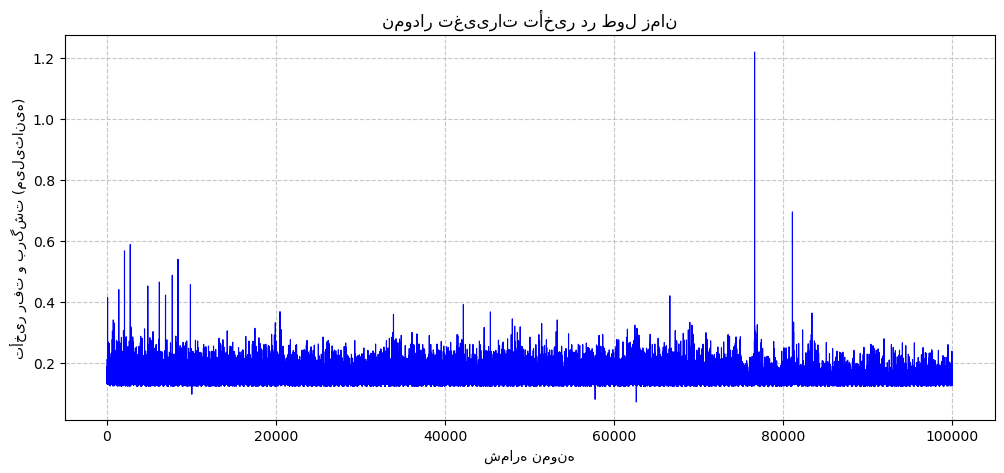

In [5]:
import socket
import time
import matplotlib.pyplot as plt

HOST = '192.168.1.10'
PORT = 7
COUNT = 100000  # تعداد تکرار

def main():
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'
    rtt_list = []
    start_time = time.perf_counter()

    for i in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt = t2 - t1
        rtt_list.append(rtt)

    end_time = time.perf_counter()
    sock.close()

    total_time = end_time - start_time
    total_bytes = COUNT * 2  # ارسال + دریافت
    throughput = total_bytes / total_time  # بایت بر ثانیه

    # تبدیل به میلی‌ثانیه برای نمودار
    rtt_ms = [r * 1000 for r in rtt_list]

    # آمار
    avg_rtt = sum(rtt_list) / COUNT * 1000
    min_rtt = min(rtt_list) * 1000
    max_rtt = max(rtt_list) * 1000

    print(f"تعداد نمونه‌ها: {COUNT}")
    print(f"کل زمان: {total_time:.4f} ثانیه")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه  ({throughput*8/1e6:.3f} Mbps)")

    # رسم نمودار
    plt.figure(figsize=(12, 5))
    plt.plot(rtt_ms, 'b-', linewidth=0.8)
    plt.xlabel('شماره نمونه')
    plt.ylabel('تأخیر رفت و برگشت (میلی‌ثانیه)')
    plt.title('نمودار تغییرات تأخیر در طول زمان')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

if __name__ == "__main__":
    main()

تعداد کل نمونه‌ها: 20000
زمان کل اجرا: 3.0528 ثانیه
پهنای باند مؤثر: 13102.83 بایت/ثانیه (معادل 0.105 Mbps)
میانگین RTT: 0.152 میلی‌ثانیه
انحراف معیار: 0.033 میلی‌ثانیه
حداقل RTT: 0.115 میلی‌ثانیه
حداکثر RTT: 1.499 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 1 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.01%


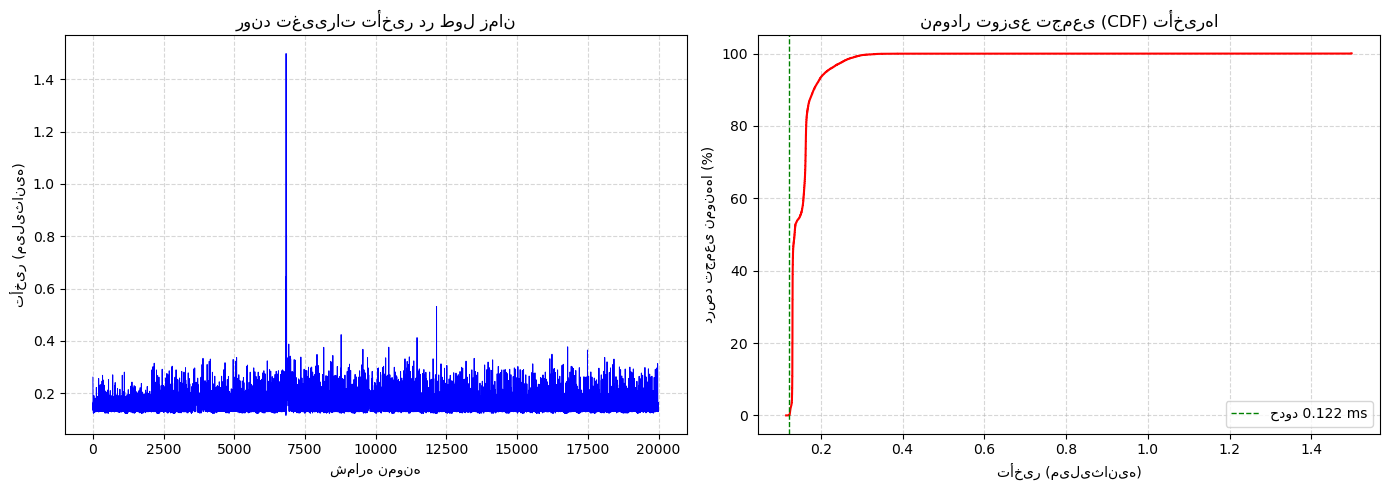

In [6]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np

# تنظیمات
HOST = '192.168.1.10'   # آدرس سرور Echo
PORT = 7                # پورت استاندارد Echo
COUNT = 20000            # تعداد تکرار (برای دقت بیشتر افزایش دهید)

def main():
    # اتصال به سرور با TCP_NODELAY برای کمترین تأخیر
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'   # یک بایت
    rtt_list = []

    start_time = time.perf_counter()

    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)

    end_time = time.perf_counter()
    sock.close()

    # تبدیل به میلی‌ثانیه
    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2   # 1 بایت ارسال + 1 بایت دریافت
    throughput = total_bytes / total_time

    # محاسبه آمار
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    # شمارش نمونه‌هایی که کمتر یا مساوی 0.122 میلی‌ثانیه هستند
    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    # چاپ نتایج عددی
    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ============= رسم نمودارها =============
    plt.figure(figsize=(14, 5))

    # نمودار 1: سری زمانی (روند تغییرات)
    plt.subplot(1, 2, 1)
    plt.plot(rtt_ms, 'b-', linewidth=0.7)
    plt.xlabel('شماره نمونه')
    plt.ylabel('تأخیر (میلی‌ثانیه)')
    plt.title('روند تغییرات تأخیر در طول زمان')
    plt.grid(True, linestyle='--', alpha=0.5)

    # نمودار 2: توزیع تجمعی (CDF)
    plt.subplot(1, 2, 2)
    sorted_rtt = np.sort(rtt_ms)
    # درصد نمونه‌هایی که کمتر یا مساوی هر مقدار هستند
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    plt.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    
    # رسم یک خط عمودی در نقطه 0.122 میلی‌ثانیه برای نمایش بهتر
    plt.axvline(x=threshold, color='green', linestyle='--', linewidth=1, label=f'حدود {threshold} ms')
    plt.xlabel('تأخیر (میلی‌ثانیه)')
    plt.ylabel('درصد تجمعی نمونه‌ها (%)')
    plt.title('نمودار توزیع تجمعی (CDF) تأخیرها')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

تعداد کل نمونه‌ها: 20000
زمان کل اجرا: 2.9769 ثانیه
پهنای باند مؤثر: 13436.79 بایت/ثانیه (معادل 0.107 Mbps)
میانگین RTT: 0.149 میلی‌ثانیه
انحراف معیار: 0.031 میلی‌ثانیه
حداقل RTT: 0.082 میلی‌ثانیه
حداکثر RTT: 0.951 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 4 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.02%


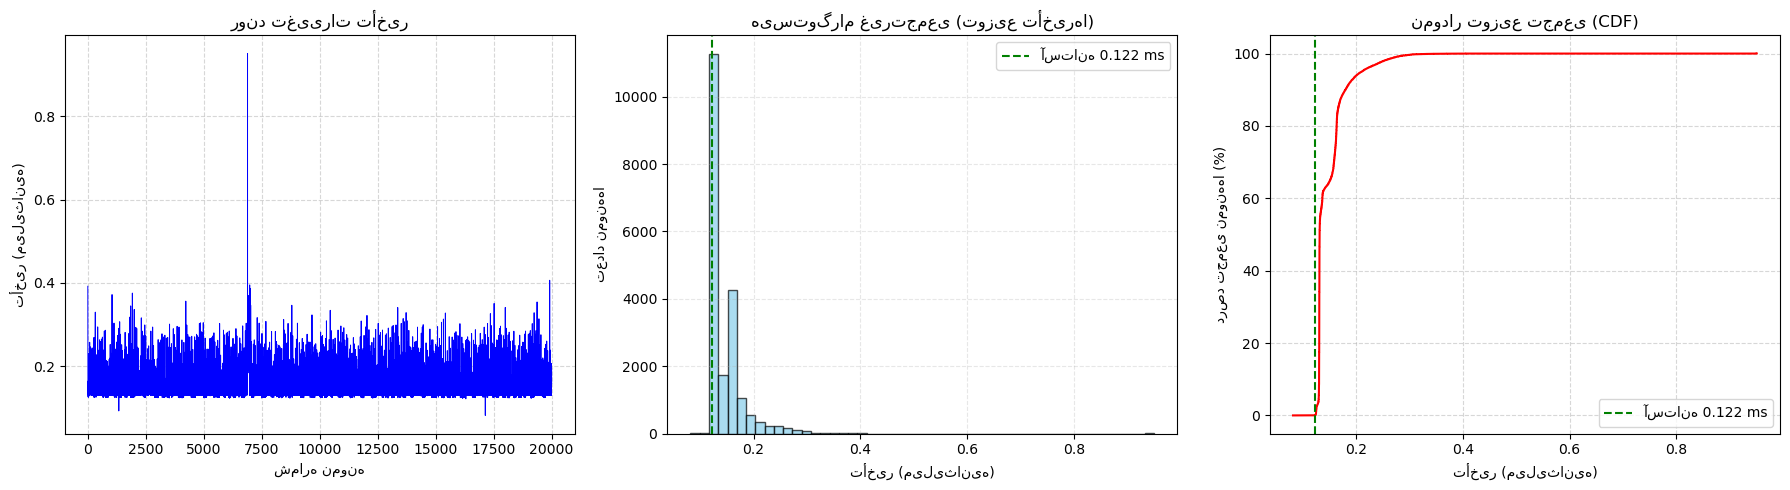

In [7]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np

# تنظیمات
HOST = '192.168.1.10'   # آدرس سرور Echo
PORT = 7                # پورت استاندارد Echo
COUNT = 20000            # تعداد تکرار (برای دقت بیشتر افزایش دهید)

def main():
    # اتصال به سرور با TCP_NODELAY برای کمترین تأخیر
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'   # یک بایت
    rtt_list = []

    start_time = time.perf_counter()

    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)

    end_time = time.perf_counter()
    sock.close()

    # تبدیل به میلی‌ثانیه
    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2   # 1 بایت ارسال + 1 بایت دریافت
    throughput = total_bytes / total_time

    # محاسبه آمار
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    # آمار مربوط به آستانه 0.122 میلی‌ثانیه
    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    # چاپ نتایج عددی
    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ============= رسم سه نمودار در کنار هم =============
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. نمودار سری زمانی (روند تغییرات)
    axes[0].plot(rtt_ms, 'b-', linewidth=0.7)
    axes[0].set_xlabel('شماره نمونه')
    axes[0].set_ylabel('تأخیر (میلی‌ثانیه)')
    axes[0].set_title('روند تغییرات تأخیر')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. هیستوگرام غیرتجمعی (توزیع فراوانی)
    axes[1].hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    axes[1].set_xlabel('تأخیر (میلی‌ثانیه)')
    axes[1].set_ylabel('تعداد نمونه‌ها')
    axes[1].set_title('هیستوگرام غیرتجمعی (توزیع تأخیرها)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # 3. نمودار تجمعی (CDF)
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    axes[2].step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    axes[2].set_xlabel('تأخیر (میلی‌ثانیه)')
    axes[2].set_ylabel('درصد تجمعی نمونه‌ها (%)')
    axes[2].set_title('نمودار توزیع تجمعی (CDF)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

تعداد کل نمونه‌ها: 2000
زمان کل اجرا: 0.2955 ثانیه
پهنای باند مؤثر: 13535.67 بایت/ثانیه (معادل 0.108 Mbps)
میانگین RTT: 0.147 میلی‌ثانیه
انحراف معیار: 0.031 میلی‌ثانیه
حداقل RTT: 0.124 میلی‌ثانیه
حداکثر RTT: 0.346 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 0 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.00%


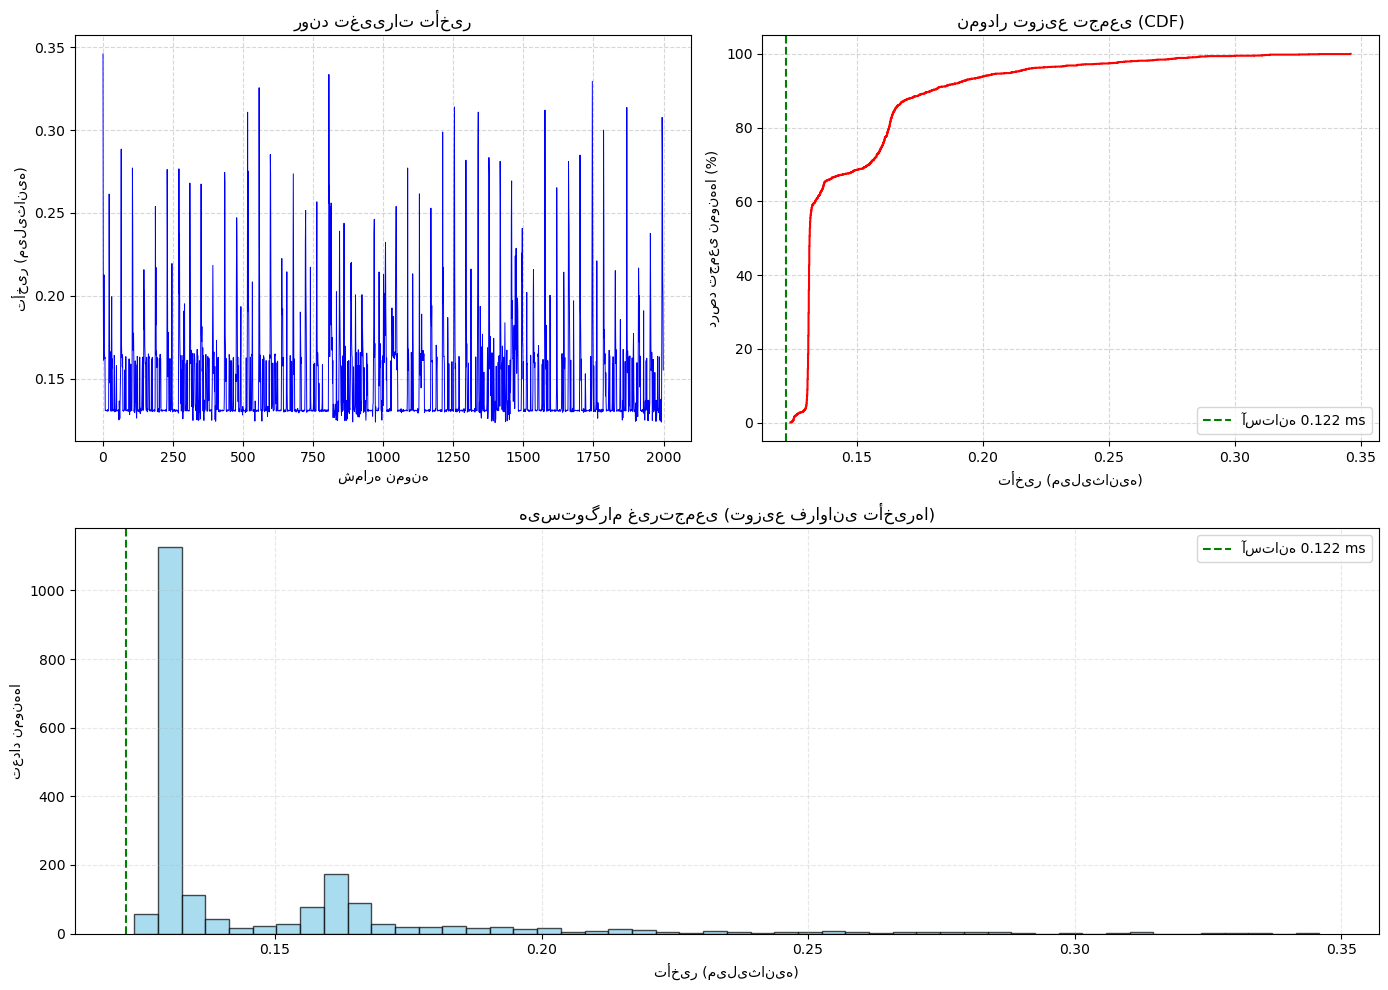

In [8]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ========== تنظیم فونت فارسی ==========
# پیدا کردن فونت‌های فارسی نصب‌شده در سیستم
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
persian_fonts = [f for f in font_list if any(name in f for name in ['Vazir', 'Sahel', 'B Nazanin', 'IRAN'])]
if persian_fonts:
    plt.rcParams['font.family'] = fm.FontProperties(fname=persian_fonts[0]).get_name()
else:
    plt.rcParams['font.family'] = 'sans-serif'  # اگر فونت فارسی نبود، از پیش‌فرض استفاده کن
plt.rcParams['axes.unicode_minus'] = False   # برای نمایش صحیح علامت منفی

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'   # آدرس سرور Echo
PORT = 7                # پورت استاندارد Echo
COUNT = 2000            # تعداد تکرار (برای دقت بیشتر افزایش دهید)

def main():
    # اتصال به سرور
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'   # یک بایت
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    # تبدیل به میلی‌ثانیه
    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2   # 1 بایت ارسال + 1 بایت دریافت
    throughput = total_bytes / total_time

    # آمار
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    # چاپ نتایج
    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم نمودارها با چیدمان دلخواه ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])  # دو ردیف، دو ستون

    # نمودار ۱: سری زمانی (ردیف اول، ستون اول)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.7)
    ax1.set_xlabel('شماره نمونه')
    ax1.set_ylabel('تأخیر (میلی‌ثانیه)')
    ax1.set_title('روند تغییرات تأخیر')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی (ردیف اول، ستون دوم)
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    ax2.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax2.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax2.set_ylabel('درصد تجمعی نمونه‌ها (%)')
    ax2.set_title('نمودار توزیع تجمعی (CDF)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی (ردیف دوم، هر دو ستون)
    ax3 = fig.add_subplot(gs[1, :])  # کل عرض ردیف دوم
    ax3.hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax3.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax3.set_ylabel('تعداد نمونه‌ها')
    ax3.set_title('هیستوگرام غیرتجمعی (توزیع فراوانی تأخیرها)')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

فونت انتخاب‌شده: DejaVu Sans
تعداد کل نمونه‌ها: 2000
زمان کل اجرا: 0.3134 ثانیه
پهنای باند مؤثر: 12763.91 بایت/ثانیه (معادل 0.102 Mbps)
میانگین RTT: 0.156 میلی‌ثانیه
انحراف معیار: 0.036 میلی‌ثانیه
حداقل RTT: 0.124 میلی‌ثانیه
حداکثر RTT: 0.565 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 0 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.00%


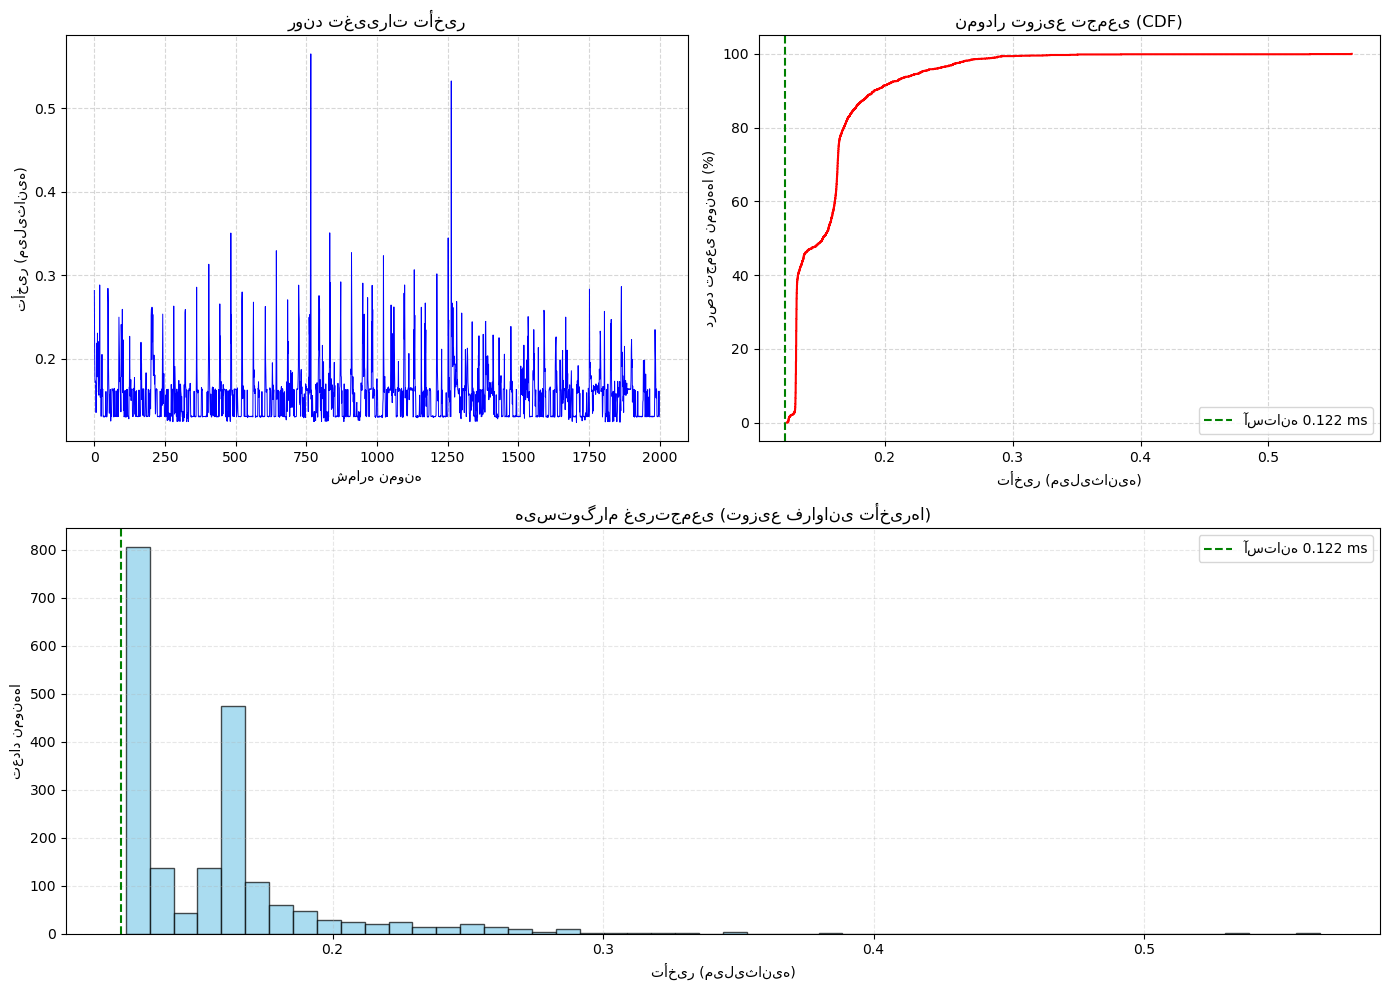

In [9]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ========== تنظیم فونت فارسی با اولویت ==========
# لیست فونت‌های احتمالی (به ترتیب اولویت)
font_candidates = [
    'DejaVu Sans',        # فونت پیش‌فرض در اکثر سیستم‌ها (فارسی و لاتین)
    'Vazir',
    'Sahel',
    'B Nazanin',
    'IRANSans',
    'Tahoma',
    'sans-serif'
]

# پیدا کردن اولین فونت موجود از لیست بالا
available_fonts = [f.name for f in fm.fontManager.ttflist]
selected_font = None
for font in font_candidates:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    plt.rcParams['font.family'] = 'sans-serif'  # آخرین راه‌حل

plt.rcParams['axes.unicode_minus'] = False  # برای نمایش صحیح علامت منفی

print(f"فونت انتخاب‌شده: {selected_font}")

# ========== بقیه کد ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 2000

def main():
    # اتصال به سرور
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time

    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم نمودارها ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.7)
    ax1.set_xlabel('شماره نمونه')
    ax1.set_ylabel('تأخیر (میلی‌ثانیه)')
    ax1.set_title('روند تغییرات تأخیر')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    ax2.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax2.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax2.set_ylabel('درصد تجمعی نمونه‌ها (%)')
    ax2.set_title('نمودار توزیع تجمعی (CDF)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی (ردیف دوم، هر دو ستون)
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax3.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax3.set_ylabel('تعداد نمونه‌ها')
    ax3.set_title('هیستوگرام غیرتجمعی (توزیع فراوانی تأخیرها)')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ فونت انتخاب‌شده: B Nazanin
در صورت عدم نمایش صحیح فارسی، فونت 'Vazir' یا 'Sahel' را نصب کنید.
تعداد کل نمونه‌ها: 200
زمان کل اجرا: 0.0319 ثانیه
پهنای باند مؤثر: 12557.65 بایت/ثانیه (معادل 0.100 Mbps)
میانگین RTT: 0.159 میلی‌ثانیه
انحراف معیار: 0.026 میلی‌ثانیه
حداقل RTT: 0.129 میلی‌ثانیه
حداکثر RTT: 0.240 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 0 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.00%


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 67 (C) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 68 (D) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 70 (F) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\400374301.py:117: UserWarning: Glyph 115 (s) missing from font(s) B Naza

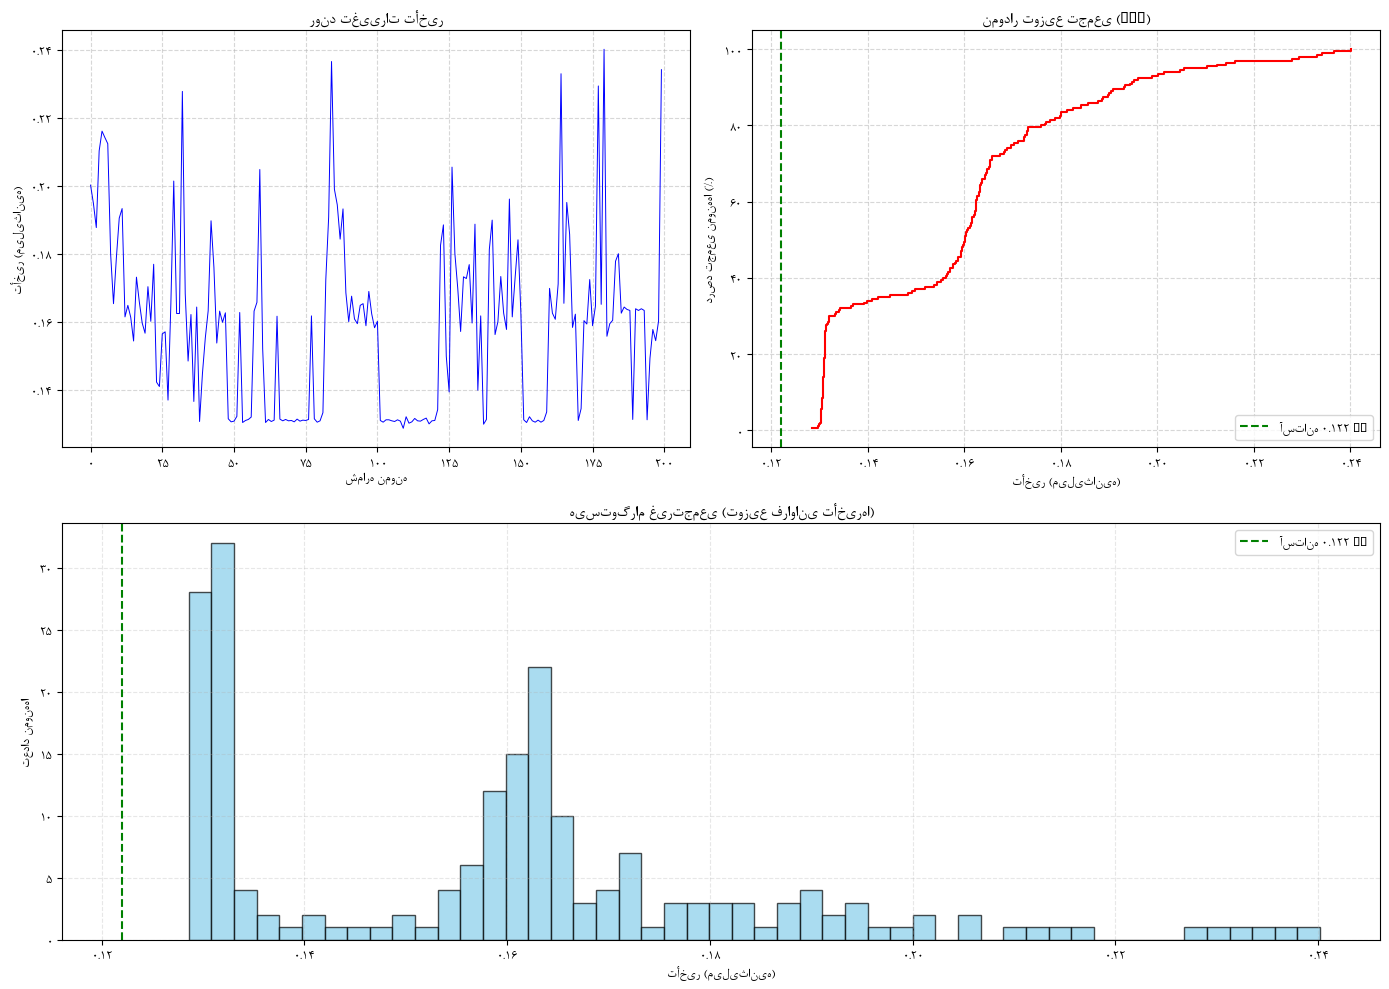

In [10]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ========== تنظیم هوشمند فونت فارسی ==========
def find_persian_font():
    """پیدا کردن یک فونت مناسب برای نمایش فارسی"""
    # لیست فونت‌های موجود در سیستم
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # اولویت فونت‌های مناسب برای فارسی
    priority_fonts = [
        'Vazir', 'Sahel', 'B Nazanin', 'IRANSans', 
        'Tahoma', 'DejaVu Sans', 'Arial', 'sans-serif'
    ]
    
    for font in priority_fonts:
        # بررسی وجود فونت به صورت دقیق (بعضی فونت‌ها با نام متفاوت ثبت شده‌اند)
        for available in available_fonts:
            if font.lower() in available.lower():
                return available
    return 'sans-serif'  # آخرین راه‌حل

selected_font = find_persian_font()
plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ فونت انتخاب‌شده: {selected_font}")
print("در صورت عدم نمایش صحیح فارسی، فونت 'Vazir' یا 'Sahel' را نصب کنید.")

# ========== بقیه کد تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 200

def main():
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time

    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم نمودارها ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.7)
    ax1.set_xlabel('شماره نمونه')
    ax1.set_ylabel('تأخیر (میلی‌ثانیه)')
    ax1.set_title('روند تغییرات تأخیر')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    ax2.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax2.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax2.set_ylabel('درصد تجمعی نمونه‌ها (%)')
    ax2.set_title('نمودار توزیع تجمعی (CDF)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی (ردیف دوم، هر دو ستون)
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax3.set_xlabel('تأخیر (میلی‌ثانیه)')
    ax3.set_ylabel('تعداد نمونه‌ها')
    ax3.set_title('هیستوگرام غیرتجمعی (توزیع فراوانی تأخیرها)')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ فونت انتخاب‌شده: B Nazanin
تعداد کل نمونه‌ها: 20000
زمان کل اجرا: 3.0234 ثانیه
پهنای باند مؤثر: 13230.06 بایت/ثانیه (معادل 0.106 Mbps)
میانگین RTT: 0.151 میلی‌ثانیه
انحراف معیار: 0.030 میلی‌ثانیه
حداقل RTT: 0.123 میلی‌ثانیه
حداکثر RTT: 0.601 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 0 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.00%


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 67 (C) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 68 (D) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 70 (F) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\892151116.py:114: UserWarning: Glyph 115 (s) missing from font(s) B Naza

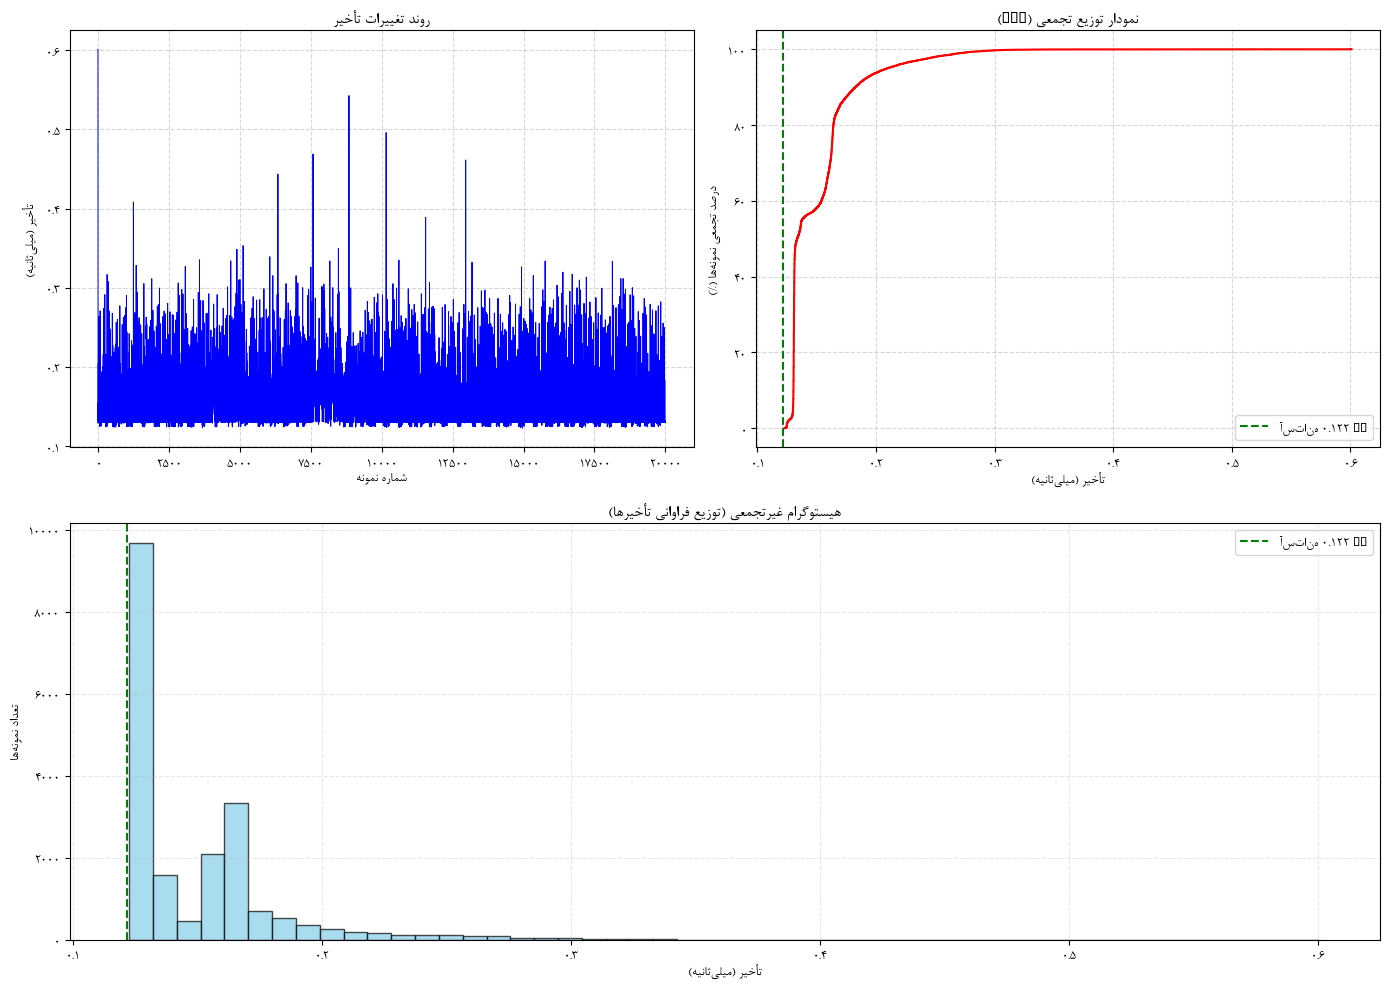

In [11]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

# ========== تابع برای اصلاح متن فارسی ==========
def fix_persian_text(text):
    """تبدیل متن فارسی به شکل قابل نمایش در matplotlib"""
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

# ========== تنظیم فونت ==========
def find_persian_font():
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    priority_fonts = ['Vazir', 'Sahel', 'B Nazanin', 'IRANSans', 'Tahoma', 'DejaVu Sans', 'Arial']
    for font in priority_fonts:
        for available in available_fonts:
            if font.lower() in available.lower():
                return available
    return 'sans-serif'

selected_font = find_persian_font()
plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
print(f"✅ فونت انتخاب‌شده: {selected_font}")

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000

def main():
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time

    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم نمودارها با متن‌های اصلاح‌شده ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.7)
    ax1.set_xlabel(fix_persian_text('شماره نمونه'))
    ax1.set_ylabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax1.set_title(fix_persian_text('روند تغییرات تأخیر'))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    ax2.step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax2.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax2.set_ylabel(fix_persian_text('درصد تجمعی نمونه‌ها (%)'))
    ax2.set_title(fix_persian_text('نمودار توزیع تجمعی (CDF)'))
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'آستانه {threshold} ms')
    ax3.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax3.set_ylabel(fix_persian_text('تعداد نمونه‌ها'))
    ax3.set_title(fix_persian_text('هیستوگرام غیرتجمعی (توزیع فراوانی تأخیرها)'))
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت پردازه به HIGH تنظیم شد و به هسته 0 محدود گردید.
تعداد کل نمونه‌ها: 20000
زمان کل اجرا: 2.9804 ثانیه
پهنای باند مؤثر: 13421.08 بایت/ثانیه (معادل 0.107 Mbps)
میانگین RTT: 0.149 میلی‌ثانیه
انحراف معیار: 0.031 میلی‌ثانیه
حداقل RTT: 0.070 میلی‌ثانیه
حداکثر RTT: 0.724 میلی‌ثانیه

تعداد نمونه‌هایی با RTT <= 0.122 میلی‌ثانیه: 3 عدد
درصد نمونه‌ها با RTT <= 0.122 میلی‌ثانیه: 0.01%


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3919667789.py:107: UserWarning: Glyph 78 (N) missing from font(s)

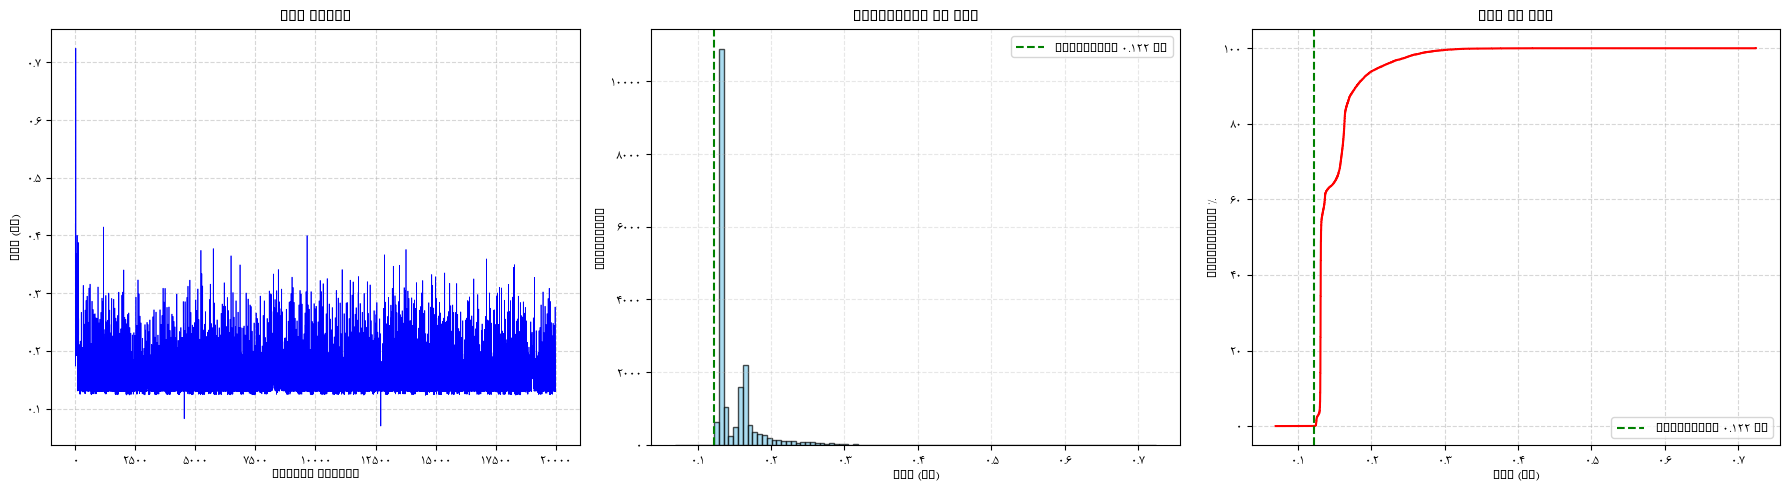

In [12]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes

# ========== تنظیم اولویت و CPU Affinity در ویندوز ==========
def set_high_priority():
    """تنظیم اولویت پردازه به HIGH در ویندوز و محدود کردن به هسته 0"""
    try:
        if sys.platform == 'win32':
            # دریافت handle پردازه جاری
            handle = ctypes.windll.kernel32.GetCurrentProcess()
            # تنظیم اولویت به HIGH_PRIORITY_CLASS (0x00000080)
            ctypes.windll.kernel32.SetPriorityClass(handle, 0x00000080)
            # محدود کردن به هسته 0 (ماسک 0x01)
            ctypes.windll.kernel32.SetProcessAffinityMask(handle, 0x01)
            print("✅ اولویت پردازه به HIGH تنظیم شد و به هسته 0 محدود گردید.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به دسترسی ادمین دارد (یا خطا): {e}")

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000  # افزایش تعداد برای دقت بیشتر

def main():
    set_high_priority()

    # ایجاد سوکت با TCP_NODELAY
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'
    rtt_list = []

    start_time = time.perf_counter()
    for _ in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter()
        rtt_list.append(t2 - t1)
    end_time = time.perf_counter()
    sock.close()

    rtt_ms = np.array(rtt_list) * 1000
    total_time = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time

    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)

    threshold = 0.122
    count_below_threshold = np.sum(rtt_ms <= threshold)
    percent_below_threshold = (count_below_threshold / COUNT) * 100

    # چاپ نتایج
    print(f"تعداد کل نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه (معادل {throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"\nتعداد نمونه‌هایی با RTT <= {threshold} میلی‌ثانیه: {count_below_threshold} عدد")
    print(f"درصد نمونه‌ها با RTT <= {threshold} میلی‌ثانیه: {percent_below_threshold:.2f}%")

    # ========== رسم سه نمودار ==========
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. سری زمانی
    axes[0].plot(rtt_ms, 'b-', linewidth=0.5)
    axes[0].set_xlabel('Sample Number')
    axes[0].set_ylabel('RTT (ms)')
    axes[0].set_title('RTT Trend')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. هیستوگرام غیرتجمعی
    axes[1].hist(rtt_ms, bins=100, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    axes[1].set_xlabel('RTT (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram of RTT')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # 3. CDF تجمعی
    sorted_rtt = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt) + 1) / len(sorted_rtt) * 100
    axes[2].step(sorted_rtt, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    axes[2].set_xlabel('RTT (ms)')
    axes[2].set_ylabel('Cumulative %')
    axes[2].set_title('CDF of RTT')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت نخ به TIME_CRITICAL تنظیم و Priority Boost غیرفعال شد.
✅ دقت تایمر سیستم به 1 میلی‌ثانیه افزایش یافت.
در حال گرم کردن اتصال...

===== نتایج اندازه‌گیری =====
تعداد نمونه‌ها: 20000
زمان کل اجرا: 2.9948 ثانیه
پهنای باند مؤثر: 13356.43 بایت/ثانیه (0.107 Mbps)
میانگین RTT: 0.149 میلی‌ثانیه
میانگین مقاوم (حذف 5% پرت): 0.145 میلی‌ثانیه
میانه RTT: 0.132 میلی‌ثانیه
انحراف معیار: 0.031 میلی‌ثانیه
حداقل RTT: 0.122 میلی‌ثانیه
حداکثر RTT: 0.387 میلی‌ثانیه
تعداد نمونه‌های ≤ 0.122 ms: 0 عدد (0.00%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 78 (N) missing from font(s)

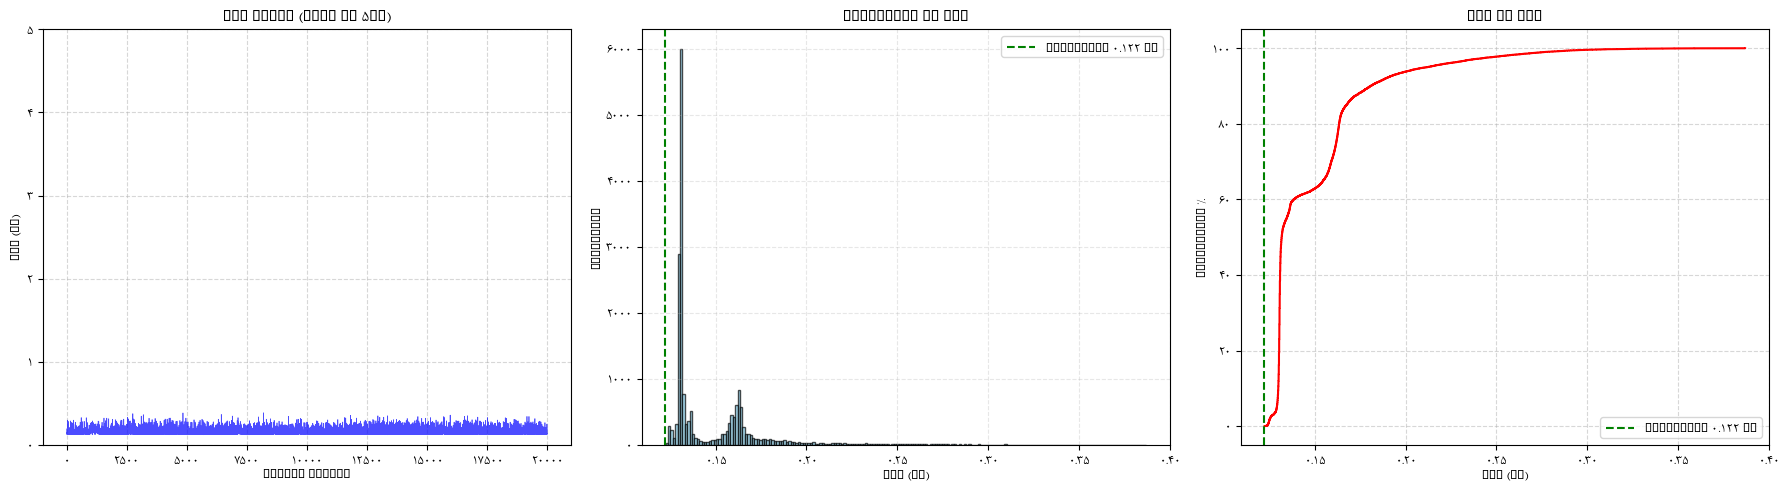

In [13]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
from ctypes import wintypes

# ========== تنظیمات ویندوز برای اولویت و دقت تایمر ==========
def set_time_critical():
    """تنظیم نخ جاری به اولویت TIME_CRITICAL و غیرفعال کردن Priority Boost"""
    try:
        # دریافت handle نخ جاری
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        # تنظیم اولویت به THREAD_PRIORITY_TIME_CRITICAL (مقدار 15)
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost برای این نخ
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        print("✅ اولویت نخ به TIME_CRITICAL تنظیم و Priority Boost غیرفعال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نخ نیاز به دسترسی ادمین دارد: {e}")

def set_high_resolution_timer():
    """افزایش دقت تایمر سیستم به 1 میلی‌ثانیه (ویندوز)"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر سیستم به 1 میلی‌ثانیه افزایش یافت.")
    except:
        pass

# ========== تنظیمات اولیه ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000               # تعداد اندازه‌گیری‌ها
WARMUP = 1000               # تعداد ارسال‌های اولیه برای گرم کردن

def main():
    # اعمال تنظیمات اولویت و تایمر
    set_time_critical()
    set_high_resolution_timer()

    # ایجاد سوکت با TCP_NODELAY و بافرهای بزرگتر
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    # افزایش بافرهای ارسال و دریافت (اختیاری)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 8192)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 8192)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'  # یک بایت

    # ===== مرحله گرم کردن (Warm-up) =====
    print("در حال گرم کردن اتصال...")
    for _ in range(WARMUP):
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))

    # ===== اندازه‌گیری اصلی =====
    rtt_list = []
    start_time = time.perf_counter_ns()  # دقت نانوثانیه

    for _ in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter_ns()
        rtt_ns = t2 - t1
        rtt_list.append(rtt_ns / 1_000_000)  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # حذف 5 درصد بالایی و پایینی برای محاسبه میانگین مقاوم (Robust)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    # آمار در آستانه 0.122 میلی‌ثانیه
    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    # چاپ نتایج
    print(f"\n===== نتایج اندازه‌گیری =====")
    print(f"تعداد نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"میانگین مقاوم (حذف 5% پرت): {trimmed_mean:.3f} میلی‌ثانیه")
    print(f"میانه RTT: {median_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"تعداد نمونه‌های ≤ {threshold} ms: {count_below} عدد ({percent_below:.2f}%)")

    # ===== رسم نمودارها (با مقیاس محدود برای دیدن جزئیات) =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. سری زمانی (محدود کردن محور y به 5 میلی‌ثانیه برای دیدن تغییرات ریز)
    ax1 = axes[0]
    ax1.plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylim(0, 5)  # محدود کردن به 5 میلی‌ثانیه
    ax1.set_xlabel('Sample Number')
    ax1.set_ylabel('RTT (ms)')
    ax1.set_title('RTT Trend (zoom to 5ms)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 2. هیستوگرام (با باین‌های بیشتر)
    ax2 = axes[1]
    ax2.hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    ax2.set_xlabel('RTT (ms)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Histogram of RTT')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.3)

    # 3. CDF
    ax3 = axes[2]
    sorted_rtt_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt_cdf) + 1) / len(sorted_rtt_cdf) * 100
    ax3.step(sorted_rtt_cdf, cdf, where='post', color='red', linewidth=1.5)
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    ax3.set_xlabel('RTT (ms)')
    ax3.set_ylabel('Cumulative %')
    ax3.set_title('CDF of RTT')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت نخ به TIME_CRITICAL تنظیم و Priority Boost غیرفعال شد.
✅ دقت تایمر سیستم به 1 میلی‌ثانیه افزایش یافت.
در حال گرم کردن اتصال...

===== نتایج اندازه‌گیری =====
تعداد نمونه‌ها: 20000
زمان کل اجرا: 2.9797 ثانیه
پهنای باند مؤثر: 13424.26 بایت/ثانیه (0.107 Mbps)
میانگین RTT: 0.148 میلی‌ثانیه
میانگین مقاوم (حذف 5% پرت): 0.144 میلی‌ثانیه
میانه RTT: 0.131 میلی‌ثانیه
انحراف معیار: 0.030 میلی‌ثانیه
حداقل RTT: 0.082 میلی‌ثانیه
حداکثر RTT: 0.382 میلی‌ثانیه
تعداد نمونه‌های ≤ 0.122 ms: 4 عدد (0.02%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3123201859.py:146: UserWarning: Glyph 78 (N) missing from font(s)

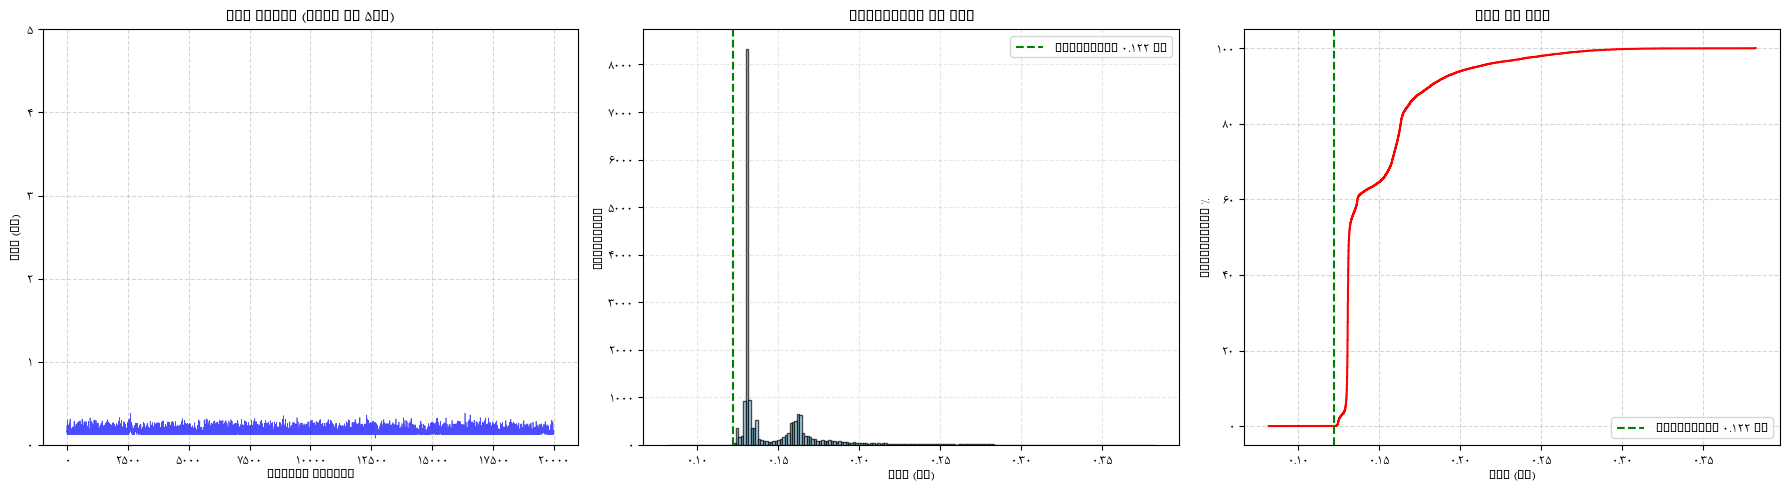

In [14]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
from ctypes import wintypes

# ========== تنظیمات ویندوز برای اولویت و دقت تایمر ==========
def set_time_critical():
    """تنظیم نخ جاری به اولویت TIME_CRITICAL و غیرفعال کردن Priority Boost"""
    try:
        # دریافت handle نخ جاری
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        # تنظیم اولویت به THREAD_PRIORITY_TIME_CRITICAL (مقدار 15)
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost برای این نخ
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        print("✅ اولویت نخ به TIME_CRITICAL تنظیم و Priority Boost غیرفعال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نخ نیاز به دسترسی ادمین دارد: {e}")

def set_high_resolution_timer():
    """افزایش دقت تایمر سیستم به 1 میلی‌ثانیه (ویندوز)"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر سیستم به 1 میلی‌ثانیه افزایش یافت.")
    except:
        pass

# ========== تنظیمات اولیه ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000               # تعداد اندازه‌گیری‌ها
WARMUP = 1000               # تعداد ارسال‌های اولیه برای گرم کردن

def main():
    # اعمال تنظیمات اولویت و تایمر
    set_time_critical()
    set_high_resolution_timer()

    # ایجاد سوکت با TCP_NODELAY و بافرهای بزرگتر
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    # افزایش بافرهای ارسال و دریافت (اختیاری)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 8192)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 8192)
    sock.settimeout(2)
    sock.connect((HOST, PORT))

    msg = b'A'  # یک بایت

    # ===== مرحله گرم کردن (Warm-up) =====
    print("در حال گرم کردن اتصال...")
    for _ in range(WARMUP):
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))

    # ===== اندازه‌گیری اصلی =====
    rtt_list = []
    start_time = time.perf_counter_ns()  # دقت نانوثانیه

    for _ in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(msg)
        data = sock.recv(1)
        while len(data) < 1:
            data += sock.recv(1 - len(data))
        t2 = time.perf_counter_ns()
        rtt_ns = t2 - t1
        rtt_list.append(rtt_ns / 1_000_000)  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # حذف 5 درصد بالایی و پایینی برای محاسبه میانگین مقاوم (Robust)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    # آمار در آستانه 0.122 میلی‌ثانیه
    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    # چاپ نتایج
    print(f"\n===== نتایج اندازه‌گیری =====")
    print(f"تعداد نمونه‌ها: {COUNT}")
    print(f"زمان کل اجرا: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند مؤثر: {throughput:.2f} بایت/ثانیه ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه")
    print(f"میانگین مقاوم (حذف 5% پرت): {trimmed_mean:.3f} میلی‌ثانیه")
    print(f"میانه RTT: {median_rtt:.3f} میلی‌ثانیه")
    print(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه")
    print(f"حداقل RTT: {min_rtt:.3f} میلی‌ثانیه")
    print(f"حداکثر RTT: {max_rtt:.3f} میلی‌ثانیه")
    print(f"تعداد نمونه‌های ≤ {threshold} ms: {count_below} عدد ({percent_below:.2f}%)")

    # ===== رسم نمودارها (با مقیاس محدود برای دیدن جزئیات) =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. سری زمانی (محدود کردن محور y به 5 میلی‌ثانیه برای دیدن تغییرات ریز)
    ax1 = axes[0]
    ax1.plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylim(0, 5)  # محدود کردن به 5 میلی‌ثانیه
    ax1.set_xlabel('Sample Number')
    ax1.set_ylabel('RTT (ms)')
    ax1.set_title('RTT Trend (zoom to 5ms)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 2. هیستوگرام (با باین‌های بیشتر)
    ax2 = axes[1]
    ax2.hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    ax2.set_xlabel('RTT (ms)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Histogram of RTT')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.3)

    # 3. CDF
    ax3 = axes[2]
    sorted_rtt_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_rtt_cdf) + 1) / len(sorted_rtt_cdf) * 100
    ax3.step(sorted_rtt_cdf, cdf, where='post', color='red', linewidth=1.5)
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Threshold {threshold} ms')
    ax3.set_xlabel('RTT (ms)')
    ax3.set_ylabel('Cumulative %')
    ax3.set_title('CDF of RTT')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی‌شده) =====
نمونه‌ها: 20000
زمان کل: 2.9496 ثانیه
پهنای باند: 13561.07 B/s (0.108 Mbps)
میانگین RTT: 0.147 ms
میانگین مقاوم: 0.143 ms
میانه: 0.131 ms
انحراف معیار: 0.029 ms
حداقل: 0.084 ms
حداکثر: 0.455 ms
≤ 0.122 ms: 4 (0.02%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 82 (R) missing from font(s)

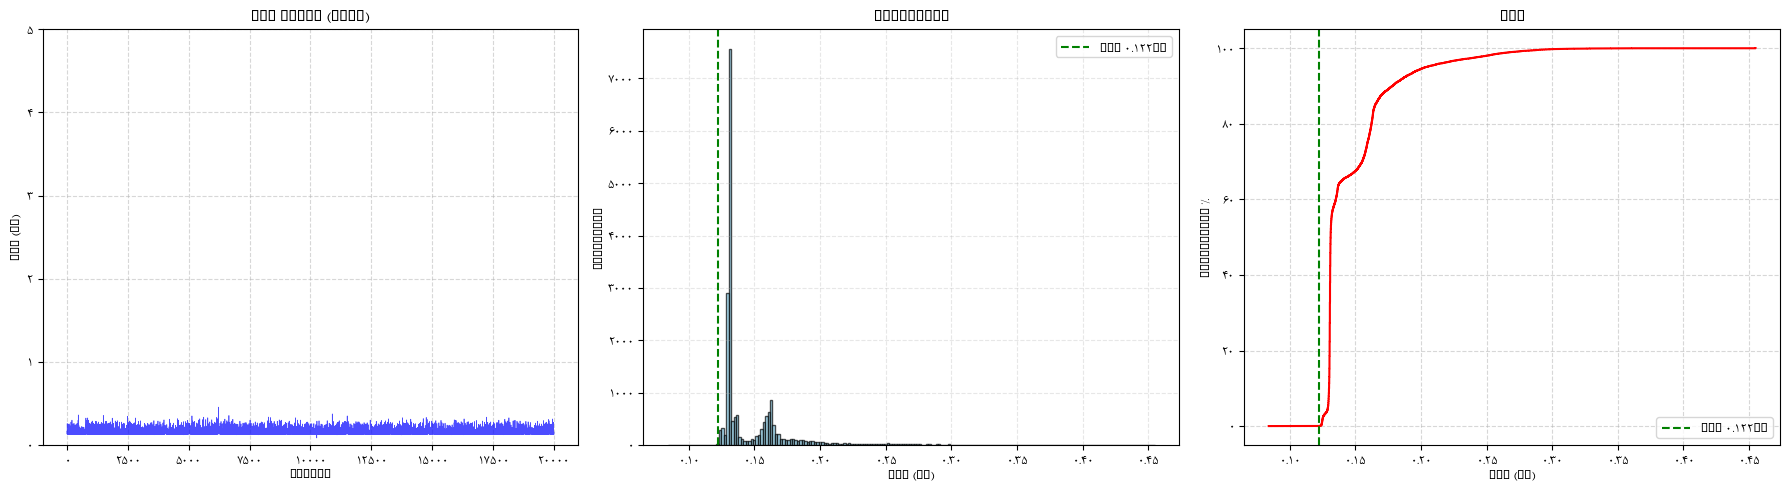

In [15]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
import gc
import os

# ========== تنظیمات ویندوز ==========
def set_realtime_priority():
    """تنظیم اولویت فرایند به REALTIME و نخ به TIME_CRITICAL"""
    try:
        # اولویت فرایند: REALTIME_PRIORITY_CLASS = 0x00000100
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)
        # اولویت نخ: THREAD_PRIORITY_TIME_CRITICAL = 15
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        # محدود کردن به هسته 0 (اختیاری)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)
        print("✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    """تنظیم دقت تایمر به 1 میلی‌ثانیه"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

# ========== غیرفعال کردن GC ==========
gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'  # یک بایت ثابت
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    # ایجاد سوکت با تنظیمات بهینه
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    # پیش‌تخصیص لیست
    rtt_list = [0.0] * COUNT

    # ===== گرم کردن =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # ===== اندازه‌گیری اصلی =====
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # میانگین مقاوم (حذف 5% پرت)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    print(f"\n===== نتایج (بهینه‌سازی‌شده) =====")
    print(f"نمونه‌ها: {COUNT}")
    print(f"زمان کل: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند: {throughput:.2f} B/s ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} ms")
    print(f"میانگین مقاوم: {trimmed_mean:.3f} ms")
    print(f"میانه: {median_rtt:.3f} ms")
    print(f"انحراف معیار: {std_rtt:.3f} ms")
    print(f"حداقل: {min_rtt:.3f} ms")
    print(f"حداکثر: {max_rtt:.3f} ms")
    print(f"≤ {threshold} ms: {count_below} ({percent_below:.2f}%)")

    # ===== رسم نمودارها =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # سری زمانی (محدود به 5ms)
    axes[0].plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    axes[0].set_ylim(0, 5)
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('RTT (ms)')
    axes[0].set_title('RTT Trend (zoom)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # هیستوگرام
    axes[1].hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[1].set_xlabel('RTT (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # CDF
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf)+1) / len(sorted_cdf) * 100
    axes[2].step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[2].set_xlabel('RTT (ms)')
    axes[2].set_ylabel('Cumulative %')
    axes[2].set_title('CDF')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی‌شده) =====
نمونه‌ها: 20000
زمان کل: 2.9330 ثانیه
پهنای باند: 13638.02 B/s (0.109 Mbps)
میانگین RTT: 0.146 ms
میانگین مقاوم: 0.142 ms
میانه: 0.131 ms
انحراف معیار: 0.028 ms
حداقل: 0.122 ms
حداکثر: 0.391 ms
≤ 0.122 ms: 0 (0.00%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 82 (R) missing from font(s)

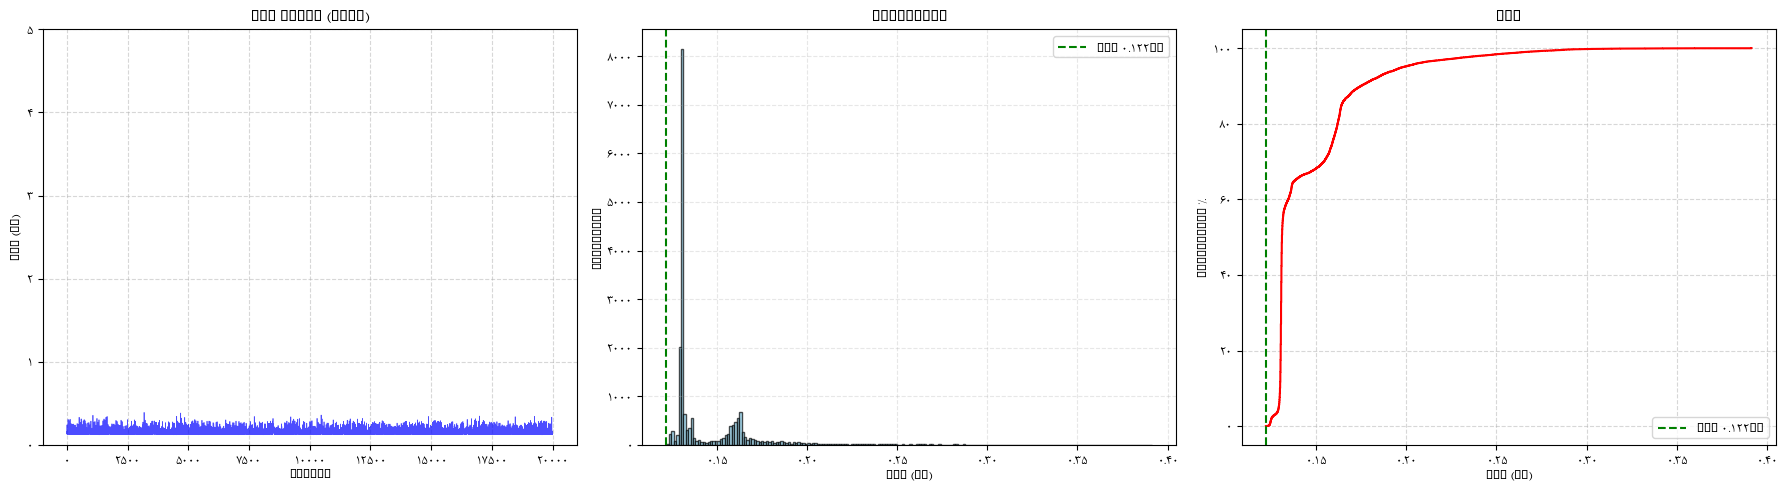

In [16]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
import gc
import os

# ========== تنظیمات ویندوز ==========
def set_realtime_priority():
    """تنظیم اولویت فرایند به REALTIME و نخ به TIME_CRITICAL"""
    try:
        # اولویت فرایند: REALTIME_PRIORITY_CLASS = 0x00000100
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)
        # اولویت نخ: THREAD_PRIORITY_TIME_CRITICAL = 15
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        # محدود کردن به هسته 0 (اختیاری)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)
        print("✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    """تنظیم دقت تایمر به 1 میلی‌ثانیه"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

# ========== غیرفعال کردن GC ==========
gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'  # یک بایت ثابت
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    # ایجاد سوکت با تنظیمات بهینه
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    # پیش‌تخصیص لیست
    rtt_list = [0.0] * COUNT

    # ===== گرم کردن =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # ===== اندازه‌گیری اصلی =====
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # میانگین مقاوم (حذف 5% پرت)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    print(f"\n===== نتایج (بهینه‌سازی‌شده) =====")
    print(f"نمونه‌ها: {COUNT}")
    print(f"زمان کل: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند: {throughput:.2f} B/s ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} ms")
    print(f"میانگین مقاوم: {trimmed_mean:.3f} ms")
    print(f"میانه: {median_rtt:.3f} ms")
    print(f"انحراف معیار: {std_rtt:.3f} ms")
    print(f"حداقل: {min_rtt:.3f} ms")
    print(f"حداکثر: {max_rtt:.3f} ms")
    print(f"≤ {threshold} ms: {count_below} ({percent_below:.2f}%)")

    # ===== رسم نمودارها =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # سری زمانی (محدود به 5ms)
    axes[0].plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    axes[0].set_ylim(0, 5)
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('RTT (ms)')
    axes[0].set_title('RTT Trend (zoom)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # هیستوگرام
    axes[1].hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[1].set_xlabel('RTT (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # CDF
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf)+1) / len(sorted_cdf) * 100
    axes[2].step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[2].set_xlabel('RTT (ms)')
    axes[2].set_ylabel('Cumulative %')
    axes[2].set_title('CDF')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی‌شده) =====
نمونه‌ها: 20000
زمان کل: 2.9302 ثانیه
پهنای باند: 13650.98 B/s (0.109 Mbps)
میانگین RTT: 0.146 ms
میانگین مقاوم: 0.142 ms
میانه: 0.131 ms
انحراف معیار: 0.028 ms
حداقل: 0.075 ms
حداکثر: 0.492 ms
≤ 0.122 ms: 4 (0.02%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2521927488.py:146: UserWarning: Glyph 82 (R) missing from font(s)

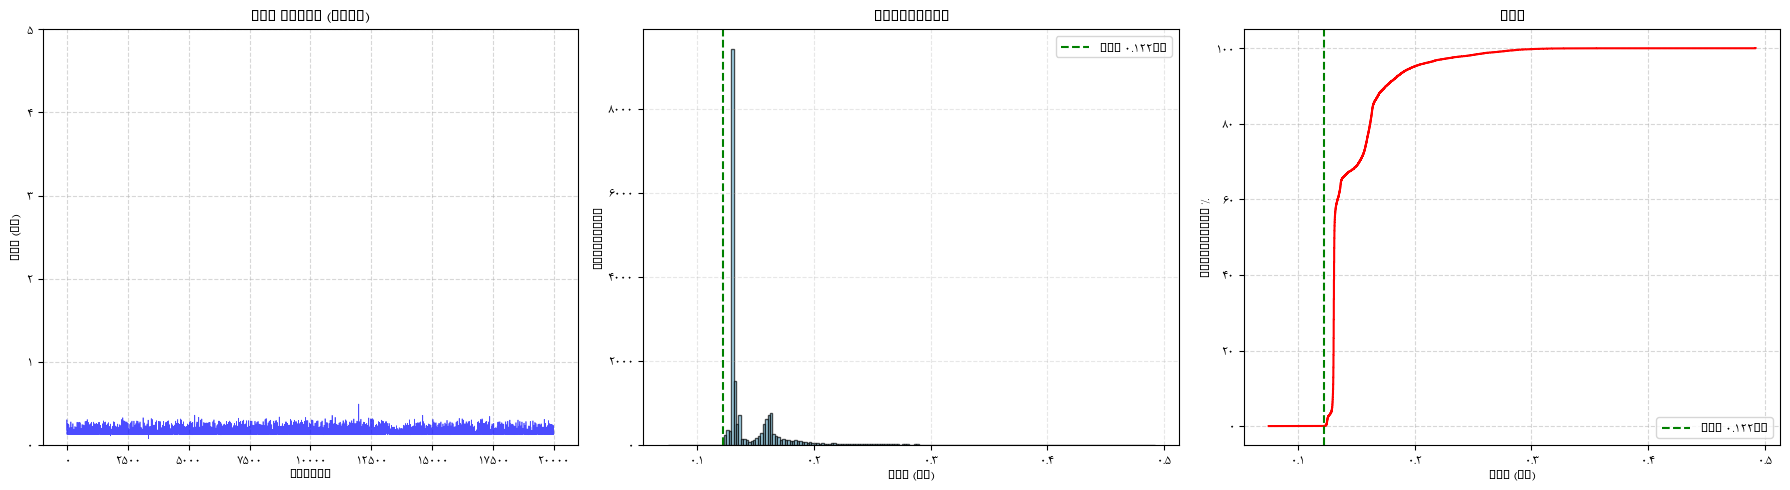

In [17]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
import gc
import os

# ========== تنظیمات ویندوز ==========
def set_realtime_priority():
    """تنظیم اولویت فرایند به REALTIME و نخ به TIME_CRITICAL"""
    try:
        # اولویت فرایند: REALTIME_PRIORITY_CLASS = 0x00000100
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)
        # اولویت نخ: THREAD_PRIORITY_TIME_CRITICAL = 15
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        # محدود کردن به هسته 0 (اختیاری)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)
        print("✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    """تنظیم دقت تایمر به 1 میلی‌ثانیه"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

# ========== غیرفعال کردن GC ==========
gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'  # یک بایت ثابت
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    # ایجاد سوکت با تنظیمات بهینه
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    # پیش‌تخصیص لیست
    rtt_list = [0.0] * COUNT

    # ===== گرم کردن =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # ===== اندازه‌گیری اصلی =====
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # میانگین مقاوم (حذف 5% پرت)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    print(f"\n===== نتایج (بهینه‌سازی‌شده) =====")
    print(f"نمونه‌ها: {COUNT}")
    print(f"زمان کل: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند: {throughput:.2f} B/s ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} ms")
    print(f"میانگین مقاوم: {trimmed_mean:.3f} ms")
    print(f"میانه: {median_rtt:.3f} ms")
    print(f"انحراف معیار: {std_rtt:.3f} ms")
    print(f"حداقل: {min_rtt:.3f} ms")
    print(f"حداکثر: {max_rtt:.3f} ms")
    print(f"≤ {threshold} ms: {count_below} ({percent_below:.2f}%)")

    # ===== رسم نمودارها =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # سری زمانی (محدود به 5ms)
    axes[0].plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    axes[0].set_ylim(0, 5)
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('RTT (ms)')
    axes[0].set_title('RTT Trend (zoom)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # هیستوگرام
    axes[1].hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[1].set_xlabel('RTT (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # CDF
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf)+1) / len(sorted_cdf) * 100
    axes[2].step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[2].set_xlabel('RTT (ms)')
    axes[2].set_ylabel('Cumulative %')
    axes[2].set_title('CDF')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی‌شده) =====
نمونه‌ها: 100000
زمان کل: 15.3726 ثانیه
پهنای باند: 13010.12 B/s (0.104 Mbps)
میانگین RTT: 0.153 ms
میانگین مقاوم: 0.150 ms
میانه: 0.143 ms
انحراف معیار: 0.029 ms
حداقل: 0.064 ms
حداکثر: 1.313 ms
≤ 0.122 ms: 19 (0.02%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\790983334.py:146: UserWarning: Glyph 82 (R) missing from font(s) B Naza

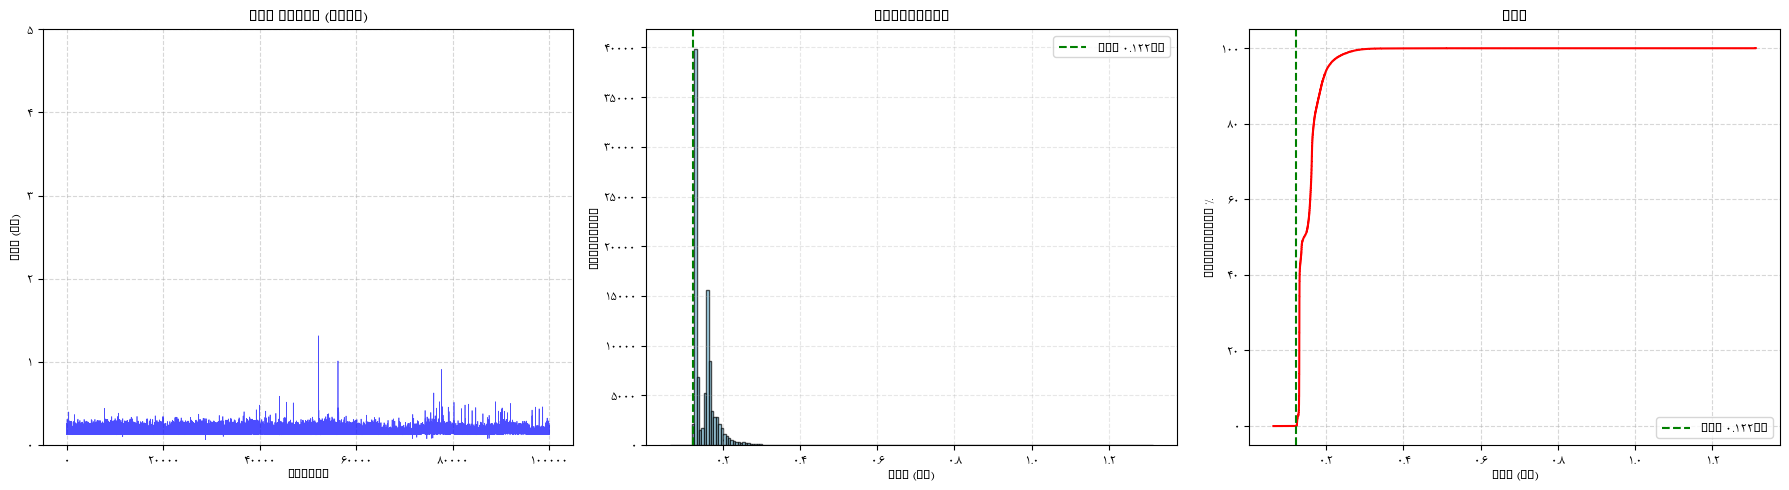

In [18]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import sys
import ctypes
import gc
import os

# ========== تنظیمات ویندوز ==========
def set_realtime_priority():
    """تنظیم اولویت فرایند به REALTIME و نخ به TIME_CRITICAL"""
    try:
        # اولویت فرایند: REALTIME_PRIORITY_CLASS = 0x00000100
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)
        # اولویت نخ: THREAD_PRIORITY_TIME_CRITICAL = 15
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        # غیرفعال کردن Priority Boost
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        # محدود کردن به هسته 0 (اختیاری)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)
        print("✅ اولویت REALTIME و TIME_CRITICAL اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    """تنظیم دقت تایمر به 1 میلی‌ثانیه"""
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

# ========== غیرفعال کردن GC ==========
gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 100000
WARMUP = 2000
MSG = b'A'  # یک بایت ثابت
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    # ایجاد سوکت با تنظیمات بهینه
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    # پیش‌تخصیص لیست
    rtt_list = [0.0] * COUNT

    # ===== گرم کردن =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # ===== اندازه‌گیری اصلی =====
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # میانگین مقاوم (حذف 5% پرت)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    print(f"\n===== نتایج (بهینه‌سازی‌شده) =====")
    print(f"نمونه‌ها: {COUNT}")
    print(f"زمان کل: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند: {throughput:.2f} B/s ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} ms")
    print(f"میانگین مقاوم: {trimmed_mean:.3f} ms")
    print(f"میانه: {median_rtt:.3f} ms")
    print(f"انحراف معیار: {std_rtt:.3f} ms")
    print(f"حداقل: {min_rtt:.3f} ms")
    print(f"حداکثر: {max_rtt:.3f} ms")
    print(f"≤ {threshold} ms: {count_below} ({percent_below:.2f}%)")

    # ===== رسم نمودارها =====
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # سری زمانی (محدود به 5ms)
    axes[0].plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    axes[0].set_ylim(0, 5)
    axes[0].set_xlabel('Sample')
    axes[0].set_ylabel('RTT (ms)')
    axes[0].set_title('RTT Trend (zoom)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # هیستوگرام
    axes[1].hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    axes[1].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[1].set_xlabel('RTT (ms)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # CDF
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf)+1) / len(sorted_cdf) * 100
    axes[2].step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    axes[2].axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    axes[2].set_xlabel('RTT (ms)')
    axes[2].set_ylabel('Cumulative %')
    axes[2].set_title('CDF')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME و TIME_CRITICAL روی هسته 0 اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی‌شده با چیدمان ۲ ردیفه) =====
نمونه‌ها: 20000
زمان کل: 3.0564 ثانیه
پهنای باند: 13087.25 B/s (0.105 Mbps)
میانگین RTT: 0.152 ms
میانگین مقاوم: 0.149 ms
میانه: 0.147 ms
انحراف معیار: 0.027 ms
حداقل: 0.071 ms
حداکثر: 0.544 ms
≤ 0.122 ms: 8 (0.04%)


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 83 (S) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 109 (m) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\2808245173.py:143: UserWarning: Glyph 78 (N) missing from font(s)

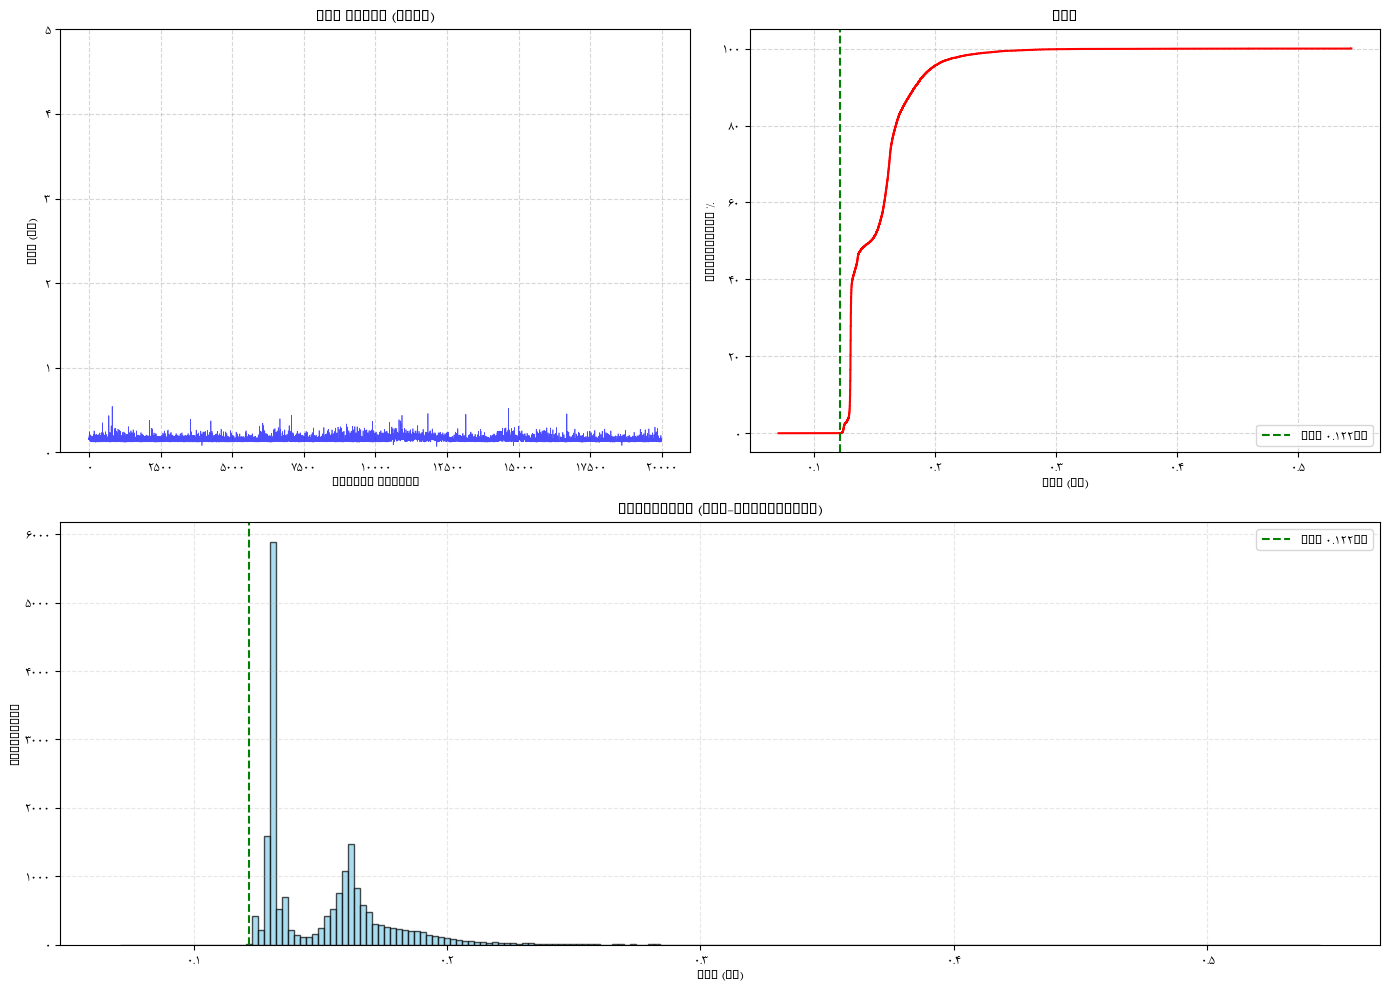

In [19]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import ctypes
import gc

# ========== تنظیمات ویندوز برای بیش‌ترین سرعت ==========
def set_realtime_priority():
    try:
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)  # REALTIME_PRIORITY_CLASS
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)          # THREAD_PRIORITY_TIME_CRITICAL
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)  # هسته 0
        print("✅ اولویت REALTIME و TIME_CRITICAL روی هسته 0 اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

# ========== غیرفعال کردن Garbage Collector ==========
gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    # ایجاد سوکت با تنظیمات بهینه
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    # پیش‌تخصیص لیست
    rtt_list = [0.0] * COUNT

    # ===== گرم کردن (Warm-up) =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # ===== اندازه‌گیری اصلی =====
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    # میانگین مقاوم (حذف 5% پرت)
    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    # چاپ نتایج
    print(f"\n===== نتایج (بهینه‌سازی‌شده با چیدمان ۲ ردیفه) =====")
    print(f"نمونه‌ها: {COUNT}")
    print(f"زمان کل: {total_time_s:.4f} ثانیه")
    print(f"پهنای باند: {throughput:.2f} B/s ({throughput*8/1e6:.3f} Mbps)")
    print(f"میانگین RTT: {avg_rtt:.3f} ms")
    print(f"میانگین مقاوم: {trimmed_mean:.3f} ms")
    print(f"میانه: {median_rtt:.3f} ms")
    print(f"انحراف معیار: {std_rtt:.3f} ms")
    print(f"حداقل: {min_rtt:.3f} ms")
    print(f"حداکثر: {max_rtt:.3f} ms")
    print(f"≤ {threshold} ms: {count_below} ({percent_below:.2f}%)")

    # ========== رسم نمودارها با چیدمان ۲ ردیفه ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی (ردیف اول، ستون چپ)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylim(0, 5)  # محدود به 5ms برای دیدن جزئیات
    ax1.set_xlabel('Sample Number')
    ax1.set_ylabel('RTT (ms)')
    ax1.set_title('RTT Trend (zoom)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF تجمعی (ردیف اول، ستون راست)
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf) + 1) / len(sorted_cdf) * 100
    ax2.step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    ax2.set_xlabel('RTT (ms)')
    ax2.set_ylabel('Cumulative %')
    ax2.set_title('CDF')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی (ردیف دوم، هر دو ستون)
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Thr {threshold}ms')
    ax3.set_xlabel('RTT (ms)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Histogram (Non-Cumulative)')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت REALTIME روی هسته 0 اعمال شد.
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج اندازه‌گیری =====
20000 :ﺎﻫﻪﻧﻮﻤﻧ ﺩﺍﺪﻌﺗ
ﻪﯿﻧﺎﺛ 3.0431 :ﻞﮐ ﻥﺎﻣﺯ
(ﻪﯿﻧﺎﺛ/ﺖﯿﺑﺎﮕﻣ 0.105) ﻪﯿﻧﺎﺛ/ﺖﯾﺎﺑ 13144.67 :ﺪﻧﺎﺑ ﯼﺎﻨﻬﭘ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ RTT: 0.151 ﻦﯿﮕﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.149 :ﻡﻭﺎﻘﻣ ﻦﯿﮕﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.143 :ﻪﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.027 :ﺭﺎﯿﻌﻣ ﻑﺍﺮﺤﻧﺍ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.049 :ﻞﻗﺍﺪﺣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.699 :ﺮﺜﮐﺍﺪﺣ
(%0.04) 8 :ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.122 ≥ ﯼﺎﻫﻪﻧﻮﻤﻧ


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3812536955.py:160: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3812536955.py:160: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3812536955.py:160: UserWarning: Glyph 67 (C) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3812536955.py:160: UserWarning: Glyph 68 (D) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\3812536955.py:160: UserWarning: Glyph 70 (F) missing from font(s) B Nazanin.
  plt.tight_layout()


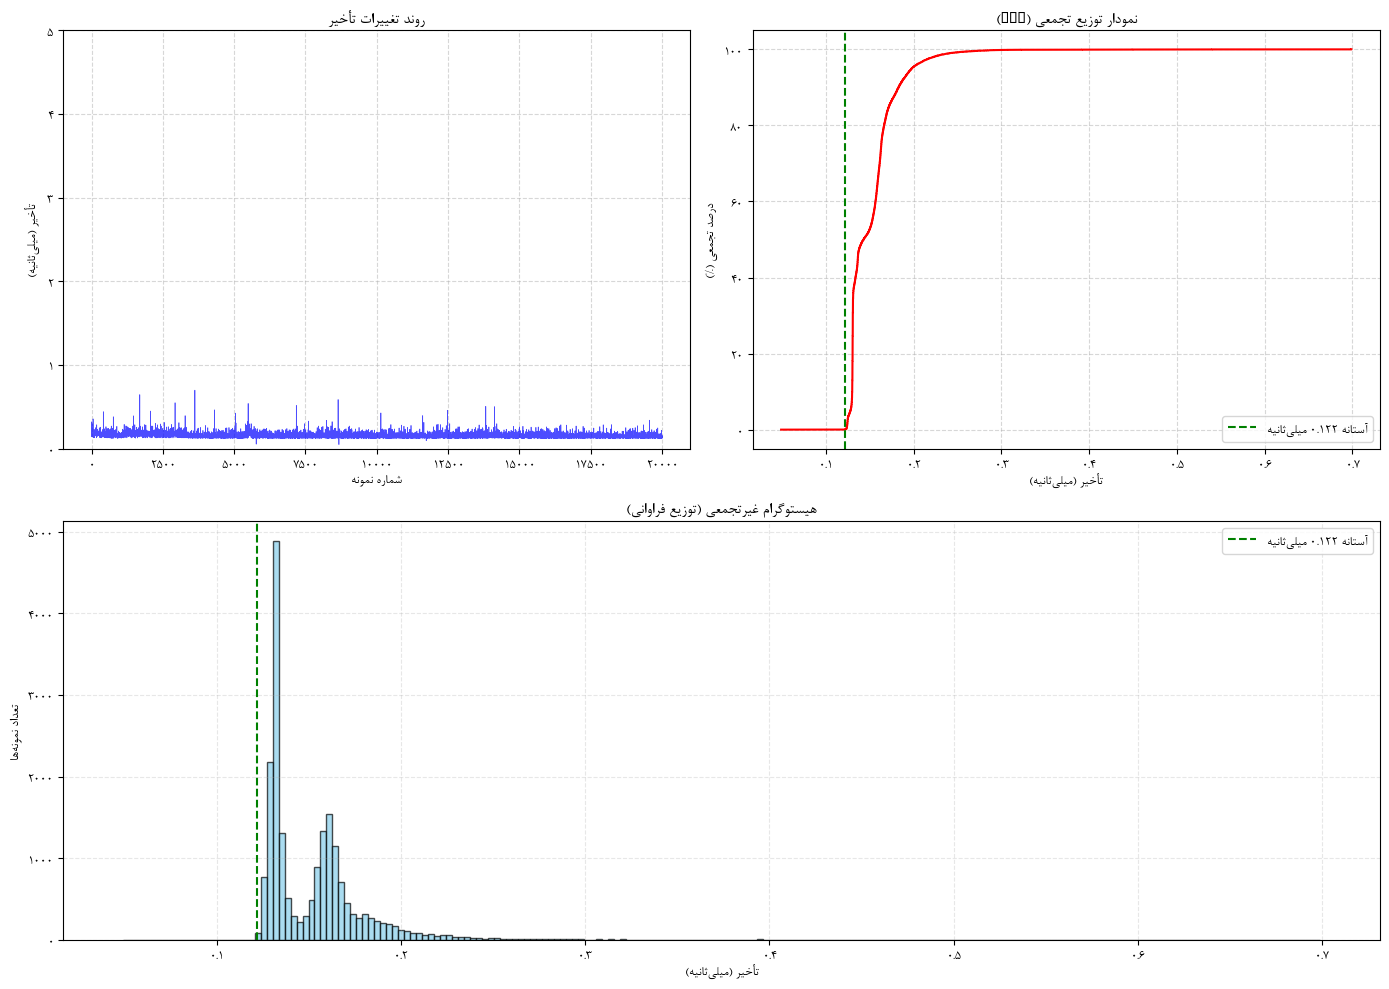

In [20]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import ctypes
import gc
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.font_manager as fm

# ========== تنظیم متن فارسی ==========
def fix_persian_text(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def find_persian_font():
    available = [f.name for f in fm.fontManager.ttflist]
    for font in ['Vazir', 'Sahel', 'B Nazanin', 'IRANSans', 'Tahoma', 'DejaVu Sans']:
        for av in available:
            if font.lower() in av.lower():
                return av
    return 'sans-serif'

plt.rcParams['font.family'] = find_persian_font()
plt.rcParams['axes.unicode_minus'] = False

# ========== تنظیمات ویندوز برای بیش‌ترین سرعت ==========
def set_realtime_priority():
    try:
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000100)
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 15)
        ctypes.windll.kernel32.SetThreadPriorityBoost(thread_handle, False)
        ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x01)
        print("✅ اولویت REALTIME روی هسته 0 اعمال شد.")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'
RECV_SIZE = 1

def main():
    set_realtime_priority()
    set_timer_resolution()

    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    rtt_list = [0.0] * COUNT

    # Warm-up
    for _ in range(WARMUP):
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))

    # اندازه‌گیری
    start_time = time.perf_counter_ns()
    for i in range(COUNT):
        t1 = time.perf_counter_ns()
        sock.sendall(MSG)
        data = sock.recv(RECV_SIZE)
        while len(data) < RECV_SIZE:
            data += sock.recv(RECV_SIZE - len(data))
        t2 = time.perf_counter_ns()
        rtt_list[i] = (t2 - t1) / 1_000_000.0

    end_time = time.perf_counter_ns()
    sock.close()

    total_time_s = (end_time - start_time) / 1_000_000_000.0
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    # چاپ نتایج فارسی
    print(f"\n===== نتایج اندازه‌گیری =====")
    print(fix_persian_text(f"تعداد نمونه‌ها: {COUNT}"))
    print(fix_persian_text(f"زمان کل: {total_time_s:.4f} ثانیه"))
    print(fix_persian_text(f"پهنای باند: {throughput:.2f} بایت/ثانیه ({throughput*8/1e6:.3f} مگابیت/ثانیه)"))
    print(fix_persian_text(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"میانگین مقاوم: {trimmed_mean:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"میانه: {median_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"حداقل: {min_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"حداکثر: {max_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"نمونه‌های ≤ {threshold} میلی‌ثانیه: {count_below} ({percent_below:.2f}%)"))

    # ========== رسم نمودارها با چیدمان ۲ ردیفه ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # نمودار ۱: سری زمانی (بالا-چپ)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylim(0, 5)
    ax1.set_xlabel(fix_persian_text('شماره نمونه'))
    ax1.set_ylabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax1.set_title(fix_persian_text('روند تغییرات تأخیر'))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۲: CDF (بالا-راست)
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf) + 1) / len(sorted_cdf) * 100
    ax2.step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, 
                label=fix_persian_text(f'آستانه {threshold} میلی‌ثانیه'))
    ax2.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax2.set_ylabel(fix_persian_text('درصد تجمعی (%)'))
    ax2.set_title(fix_persian_text('نمودار توزیع تجمعی (CDF)'))
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # نمودار ۳: هیستوگرام غیرتجمعی (پایین-تمام عرض)
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5,
                label=fix_persian_text(f'آستانه {threshold} میلی‌ثانیه'))
    ax3.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax3.set_ylabel(fix_persian_text('تعداد نمونه‌ها'))
    ax3.set_title(fix_persian_text('هیستوگرام غیرتجمعی (توزیع فراوانی)'))
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

✅ اولویت HIGH اعمال شد (بدون محدودیت هسته).
✅ دقت تایمر 1ms تنظیم شد.

===== نتایج (بهینه‌سازی بدون REALTIME) =====
20000 :ﺎﻫﻪﻧﻮﻤﻧ ﺩﺍﺪﻌﺗ
ﻪﯿﻧﺎﺛ 2.9931 :ﻞﮐ ﻥﺎﻣﺯ
(ﻪﯿﻧﺎﺛ/ﺖﯿﺑﺎﮕﻣ 0.107) ﻪﯿﻧﺎﺛ/ﺖﯾﺎﺑ 13364.14 :ﺪﻧﺎﺑ ﯼﺎﻨﻬﭘ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ RTT: 0.149 ﻦﯿﮕﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.146 :ﻡﻭﺎﻘﻣ ﻦﯿﮕﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.136 :ﻪﻧﺎﯿﻣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.027 :ﺭﺎﯿﻌﻣ ﻑﺍﺮﺤﻧﺍ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.096 :ﻞﻗﺍﺪﺣ
ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.473 :ﺮﺜﮐﺍﺪﺣ
(%0.01) 3 :ﻪﯿﻧﺎﺛﯽﻠﯿﻣ 0.122 ≥ ﯼﺎﻫﻪﻧﻮﻤﻧ


C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\180748420.py:157: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\180748420.py:157: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\180748420.py:157: UserWarning: Glyph 67 (C) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\180748420.py:157: UserWarning: Glyph 68 (D) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_32500\180748420.py:157: UserWarning: Glyph 70 (F) missing from font(s) B Nazanin.
  plt.tight_layout()


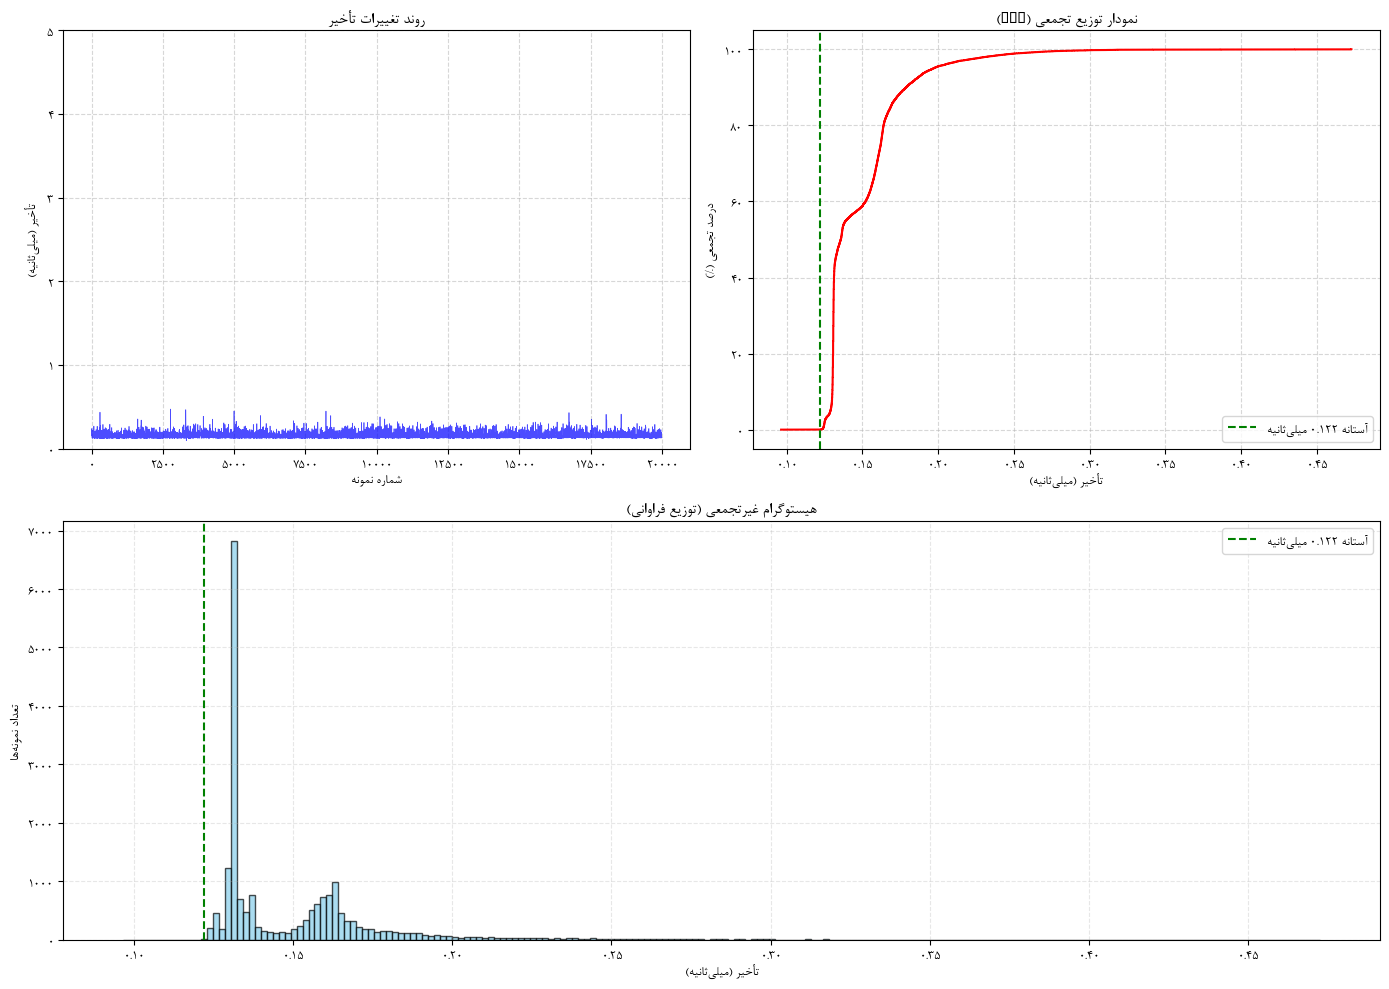

In [21]:
import socket
import time
import matplotlib.pyplot as plt
import numpy as np
import ctypes
import gc
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.font_manager as fm

# ========== تنظیم متن فارسی ==========
def fix_persian_text(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

def find_persian_font():
    available = [f.name for f in fm.fontManager.ttflist]
    for font in ['Vazir', 'Sahel', 'B Nazanin', 'IRANSans', 'Tahoma', 'DejaVu Sans']:
        for av in available:
            if font.lower() in av.lower():
                return av
    return 'sans-serif'

plt.rcParams['font.family'] = find_persian_font()
plt.rcParams['axes.unicode_minus'] = False

# ========== تنظیمات ویندوز (بهینه شده بدون REALTIME) ==========
def set_high_priority():
    """تنظیم اولویت HIGH (نه REALTIME) و بدون محدودیت هسته"""
    try:
        process_handle = ctypes.windll.kernel32.GetCurrentProcess()
        # HIGH_PRIORITY_CLASS = 0x00000080 (کافی و بدون تداخل با وقفه‌ها)
        ctypes.windll.kernel32.SetPriorityClass(process_handle, 0x00000080)
        thread_handle = ctypes.windll.kernel32.GetCurrentThread()
        # THREAD_PRIORITY_HIGHEST = 2 (بالا ولی نه TIME_CRITICAL)
        ctypes.windll.kernel32.SetThreadPriority(thread_handle, 2)
        # حذف محدودیت هسته (یا اگر می‌خواهید، به هسته 1 یا 2 بچسبانید تا با هسته وقفه تداخل نداشته باشد)
        # ctypes.windll.kernel32.SetProcessAffinityMask(process_handle, 0x02)  # هسته 1
        print("✅ اولویت HIGH اعمال شد (بدون محدودیت هسته).")
    except Exception as e:
        print(f"⚠️  تنظیم اولویت نیاز به ادمین دارد: {e}")

def set_timer_resolution():
    try:
        ctypes.windll.winmm.timeBeginPeriod(1)
        print("✅ دقت تایمر 1ms تنظیم شد.")
    except:
        pass

gc.disable()

# ========== تنظیمات تست ==========
HOST = '192.168.1.10'
PORT = 7
COUNT = 20000
WARMUP = 2000
MSG = b'A'

def main():
    set_high_priority()
    set_timer_resolution()

    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, 65536)
    sock.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, 65536)
    sock.settimeout(1)
    sock.connect((HOST, PORT))

    rtt_list = [0.0] * COUNT

    # ===== گرم کردن =====
    for _ in range(WARMUP):
        sock.sendall(MSG)
        sock.recv(1)  # دقیقاً ۱ بایت، نیازی به حلقه while نیست

    # ===== اندازه‌گیری اصلی (استفاده از perf_counter به جای perf_counter_ns) =====
    start_time = time.perf_counter()
    for i in range(COUNT):
        t1 = time.perf_counter()
        sock.sendall(MSG)
        sock.recv(1)  # دریافت یک بایت
        t2 = time.perf_counter()
        rtt_list[i] = (t2 - t1) * 1000.0  # تبدیل به میلی‌ثانیه

    end_time = time.perf_counter()
    sock.close()

    total_time_s = end_time - start_time
    total_bytes = COUNT * 2
    throughput = total_bytes / total_time_s

    rtt_ms = np.array(rtt_list)
    avg_rtt = np.mean(rtt_ms)
    min_rtt = np.min(rtt_ms)
    max_rtt = np.max(rtt_ms)
    std_rtt = np.std(rtt_ms)
    median_rtt = np.median(rtt_ms)

    sorted_rtt = np.sort(rtt_ms)
    trim = int(0.05 * COUNT)
    trimmed_mean = np.mean(sorted_rtt[trim:COUNT-trim]) if COUNT > 2*trim else avg_rtt

    threshold = 0.122
    count_below = np.sum(rtt_ms <= threshold)
    percent_below = (count_below / COUNT) * 100

    print(f"\n===== نتایج (بهینه‌سازی بدون REALTIME) =====")
    print(fix_persian_text(f"تعداد نمونه‌ها: {COUNT}"))
    print(fix_persian_text(f"زمان کل: {total_time_s:.4f} ثانیه"))
    print(fix_persian_text(f"پهنای باند: {throughput:.2f} بایت/ثانیه ({throughput*8/1e6:.3f} مگابیت/ثانیه)"))
    print(fix_persian_text(f"میانگین RTT: {avg_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"میانگین مقاوم: {trimmed_mean:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"میانه: {median_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"انحراف معیار: {std_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"حداقل: {min_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"حداکثر: {max_rtt:.3f} میلی‌ثانیه"))
    print(fix_persian_text(f"نمونه‌های ≤ {threshold} میلی‌ثانیه: {count_below} ({percent_below:.2f}%)"))

    # ========== رسم نمودارها با چیدمان ۲ ردیفه ==========
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    # ۱. سری زمانی (بالا-چپ)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(rtt_ms, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylim(0, 5)  # محدود به ۵ میلی‌ثانیه برای دیدن جزئیات
    ax1.set_xlabel(fix_persian_text('شماره نمونه'))
    ax1.set_ylabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax1.set_title(fix_persian_text('روند تغییرات تأخیر'))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # ۲. CDF (بالا-راست)
    ax2 = fig.add_subplot(gs[0, 1])
    sorted_cdf = np.sort(rtt_ms)
    cdf = np.arange(1, len(sorted_cdf) + 1) / len(sorted_cdf) * 100
    ax2.step(sorted_cdf, cdf, where='post', color='red', linewidth=1.5)
    ax2.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5, 
                label=fix_persian_text(f'آستانه {threshold} میلی‌ثانیه'))
    ax2.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax2.set_ylabel(fix_persian_text('درصد تجمعی (%)'))
    ax2.set_title(fix_persian_text('نمودار توزیع تجمعی (CDF)'))
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # ۳. هیستوگرام غیرتجمعی (پایین-تمام عرض)
    ax3 = fig.add_subplot(gs[1, :])
    ax3.hist(rtt_ms, bins=200, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(x=threshold, color='green', linestyle='--', linewidth=1.5,
                label=fix_persian_text(f'آستانه {threshold} میلی‌ثانیه'))
    ax3.set_xlabel(fix_persian_text('تأخیر (میلی‌ثانیه)'))
    ax3.set_ylabel(fix_persian_text('تعداد نمونه‌ها'))
    ax3.set_title(fix_persian_text('هیستوگرام غیرتجمعی (توزیع فراوانی)'))
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()